# 1. Comprensión del Negocio
## Problema, hipótesis estadísticas formales y criterios de éxito

# 1.1 Descripción del Problema

El Alzheimer es una enfermedad neurodegenerativa progresiva que representa la forma más común de demencia en adultos mayores. El diagnóstico temprano es crucial para planificar el cuidado del paciente y ralentizar el avance de la enfermedad, pero suele ser complejo debido a la cantidad de factores involucrados, como los genéticos, de estilo de vida y clínicos.

Este proyecto utiliza un dataset sintético de 2,149 pacientes con el objetivo de identificar los factores de riesgo más significativos y construir modelos predictivos que permitan clasificar si un paciente tiene Alzheimer o no, basándose en datos demográficos, de estilo de vida, historial médico y evaluaciones cognitivas.

# 1.2 Objetivo del Proyecto

El objetivo principal es desarrollar un sistema de clasificación binaria:

- `0` = No Alzheimer
- `1` = Alzheimer

mediante técnicas de minería de datos.

La pregunta de investigación que guía este proyecto es:

**¿Qué variables clínicas y de estilo de vida son los predictores más fuertes para el diagnóstico de Alzheimer en esta población?**

# 1.3 Hipótesis Estadísticas Formales

Para guiar el análisis exploratorio, se plantean las siguientes hipótesis que serán validadas con pruebas estadísticas.

## A. Sobre variables numéricas
**Prueba de Mann-Whitney U**

Se sospecha que las evaluaciones cognitivas difieren significativamente entre grupos.

- **H0 (Nula):** No existe diferencia significativa en la mediana del puntaje MMSE entre pacientes diagnosticados con Alzheimer y pacientes no diagnosticados.
- **H1 (Alternativa):** La mediana del puntaje MMSE es significativamente diferente y menor en pacientes con diagnóstico de Alzheimer.

## B. Sobre variables categóricas/binarias
**Prueba Chi-cuadrado**

Se sospecha que el historial familiar es un factor de riesgo.

- **H0 (Nula):** El antecedente familiar de Alzheimer (`FamilyHistoryAlzheimers`) es independiente del diagnóstico de la enfermedad.
- **H1 (Alternativa):** Existe una asociación significativa entre el antecedente familiar y el diagnóstico de Alzheimer.

# 1.4 Criterios de Éxito

El proyecto se considerará exitoso si se cumplen los siguientes criterios técnicos y de negocio:

## Hallazgos estadísticos
Identificar al menos 3 variables con una correlación estadísticamente significativa (`p-value < 0.05`) con el diagnóstico, validadas mediante las pruebas pertinentes, como Mann-Whitney U o Chi-cuadrado.

## Rendimiento del modelo
Desarrollar al menos un modelo predictivo, como SVM, Regresión Logística o k-NN, con:

- `Accuracy` superior al umbral base.
- `AUC` superior a `0.70`.

Esto demostraría capacidad predictiva real.

## Calidad técnica
Realizar un preprocesamiento robusto, con manejo de outliers y escalado justificado estadísticamente, evitando `data leakage` y validando la estabilidad de los modelos mediante `Bootstrap` y `Cross-validation`.

In [ ]:
import pandas as pd
import kagglehub
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import learning_curve
from sklearn.metrics import classification_report, confusion_matrix
from kagglehub import KaggleDatasetAdapter
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif, RFE, SelectFromModel, SequentialFeatureSelector
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
import numpy as np

import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.stats.contingency_tables import mcnemar
import numpy as np
from sklearn.utils import resample
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

import seaborn as sns
from scipy.stats import shapiro
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu
from scipy.stats import chi2_contingency
import numpy as np
import math
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy.stats import entropy
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif, RFE, SelectFromModel, SequentialFeatureSelector
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
!pip install Boruta
from boruta import BorutaPy
warnings.filterwarnings('ignore')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.9/57.9 kB 2.4 MB/s eta 0:00:00


# 2. Comprencion de los datos.

## EDA Estadístico Profundo

### Cargar datos

In [ ]:
# --- 1. Carga de Datos ---
file_path = "alzheimers_disease_data.csv"

print("⏳ Descargando y cargando dataset...")

df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "rabieelkharoua/alzheimers-disease-dataset",
    file_path,
)

# --- 2. Vista Preia ---
# Mostramos las primeras 5 filas
print("\n📋 Primeras 5 filas del dataset:")
display(df.head())

⏳ Descargando y cargando dataset...


100%|██████████| 591k/591k [00:00<00:00, 7.07MB/s]


📋 Primeras 5 filas del dataset:


,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis,DoctorInCharge
0,4751,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,...,0,0,1.725883,0,0,0,1,0,0,XXXConfid
1,4752,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,...,0,0,2.592424,0,0,0,0,1,0,XXXConfid
2,4753,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,...,0,0,7.119548,0,1,0,1,0,0,XXXConfid
3,4754,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,...,0,1,6.481226,0,0,0,0,0,0,XXXConfid
4,4755,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,...,0,0,0.014691,0,0,1,1,0,0,XXXConfid


### Renombrar variables

In [ ]:
# --- Renombramiento de Variables a Español (Corregido) ---
# Se usa el diccionario con los nombres EXACTOS que vienen en el CSV (PascalCase)

nuevos_nombres = {
    'PatientID': 'ID_Paciente',
    'Age': 'Edad',
    'Gender': 'Género',
    'Ethnicity': 'Etnia',
    'EducationLevel': 'Nivel_Educación',
    'BMI': 'IMC',
    'Smoking': 'Fumador',
    'AlcoholConsumption': 'Consumo_Alcohol',
    'PhysicalActivity': 'Actividad_Física',
    'DietQuality': 'Calidad_Dieta',
    'SleepQuality': 'Calidad_Sueño',
    'FamilyHistoryAlzheimers': 'Antecedentes_Familiares',
    'CardiovascularDisease': 'Enfermedad_Cardiovascular',
    'Diabetes': 'Diabetes',
    'Depression': 'Depresión',
    'HeadInjury': 'Lesión_Cerebral',
    'Hypertension': 'Hipertensión',
    'SystolicBP': 'Presión_Sistólica',
    'DiastolicBP': 'Presión_Diastólica',
    'CholesterolTotal': 'Colesterol_Total',
    'CholesterolLDL': 'Colesterol_LDL',
    'CholesterolHDL': 'Colesterol_HDL',
    'CholesterolTriglycerides': 'Triglicéridos',
    'MMSE': 'Examen_Mini_Mental',
    'FunctionalAssessment': 'Evaluación_Funcional',
    'MemoryComplaints': 'Quejas_Memoria',
    'BehavioralProblems': 'Problemas_Conducta',
    'ADL': 'Actividades_Diarias',
    'Confusion': 'Confusión',
    'Disorientation': 'Desorientación',
    'PersonalityChanges': 'Cambios_Personalidad',
    'DifficultyCompletingTasks': 'Dificultad_Tareas',
    'Forgetfulness': 'Olvido',
    'Diagnosis': 'Diagnóstico',
    'DoctorInCharge': 'Doctor_Encargado'
}

# Aplicamos el renombramiento al dataframe existente
df.rename(columns=nuevos_nombres, inplace=True)

print("✅ Variables renombradas correctamente al español.")
print("\n📋 Vista previa con nuevos nombres:")
display(df.head())

✅ Variables renombradas correctamente al español.

📋 Vista previa con nuevos nombres:


,ID_Paciente,Edad,Género,Etnia,Nivel_Educación,IMC,Fumador,Consumo_Alcohol,Actividad_Física,Calidad_Dieta,...,Quejas_Memoria,Problemas_Conducta,Actividades_Diarias,Confusión,Desorientación,Cambios_Personalidad,Dificultad_Tareas,Olvido,Diagnóstico,Doctor_Encargado
0,4751,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,...,0,0,1.725883,0,0,0,1,0,0,XXXConfid
1,4752,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,...,0,0,2.592424,0,0,0,0,1,0,XXXConfid
2,4753,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,...,0,0,7.119548,0,1,0,1,0,0,XXXConfid
3,4754,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,...,0,1,6.481226,0,0,0,0,0,0,XXXConfid
4,4755,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,...,0,0,0.014691,0,0,1,1,0,0,XXXConfid


### Estadisticas Basicas

In [ ]:
# 1. Configuración para visualización (evita que se corte la tabla)
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 1000)

# 2. Cálculo de estadísticos
# Transponemos para que las variables sean filas y las estadísticas columnas
# .iloc[1:] elimina la fila 'count' (conteo) que suele ser la primera
stats_df = df.describe().round(3).iloc[1:].T

# 3. Formato y Estilo
styled_stats = stats_df.style.background_gradient(cmap='Blues', axis=1, subset=['mean', 'std', 'min', '25%', '50%', '75%', 'max'])\
                            .set_properties(**{'text-align': 'center'})\
                            .set_caption("📊 Resumen Estadístico de Variables Numéricas")

display(styled_stats)

,mean,std,min,25%,50%,75%,max
ID_Paciente,5825.000000,620.507000,4751.000000,5288.000000,5825.000000,6362.000000,6899.000000
Edad,74.909000,8.990000,60.000000,67.000000,75.000000,83.000000,90.000000
Género,0.506000,0.500000,0.000000,0.000000,1.000000,1.000000,1.000000
Etnia,0.698000,0.996000,0.000000,0.000000,0.000000,1.000000,3.000000
Nivel_Educación,1.287000,0.905000,0.000000,1.000000,1.000000,2.000000,3.000000
IMC,27.656000,7.217000,15.009000,21.611000,27.824000,33.870000,39.993000
Fumador,0.289000,0.453000,0.000000,0.000000,0.000000,1.000000,1.000000
Consumo_Alcohol,10.039000,5.758000,0.002000,5.140000,9.934000,15.158000,19.989000
Actividad_Física,4.920000,2.857000,0.004000,2.571000,4.766000,7.428000,9.987000
Calidad_Dieta,4.993000,2.909000,0.009000,2.458000,5.076000,7.559000,9.998000


### Diccionario de variables del dataset

| Variable Original (CSV) | Variable Nueva (Español) | Descripción |
| :--- | :--- | :--- |
| `patient_id` | `ID_Paciente` | Identificador único del paciente (4751 a 6900). |
| `age` | `Edad` | Edad del paciente en años (60 a 90). |
| `gender` | `Género` | Género: 0 = Masculino, 1 = Femenino. |
| `ethnicity` | `Etnia` | Etnia: 0 = Caucásico, 1 = Afroamericano, 2 = Asiático, 3 = Otro. |
| `education_level` | `Nivel_Educación` | Nivel educativo: 0 = Ninguno, 1 = Secundaria, 2 = Grado, 3 = Superior. |
| `bmi` | `IMC` | Índice de Masa Corporal (15 a 40). |
| `smoking` | `Fumador` | Estado de fumador: 0 = No, 1 = Sí. |
| `alcohol_consumption` | `Consumo_Alcohol` | Consumo semanal de alcohol en unidades (0 a 20). |
| `physical_activity` | `Actividad_Física` | Horas de actividad física semanal (0 a 10). |
| `diet_qualit` | `Calidad_Dieta` | Puntuación de calidad de la dieta (0 a 10). |
| `sleep_quality` | `Calidad_Sueño` | Puntuación de calidad del sueño (4 a 10). |
| `family_history_alzheimers` | `Antecedentes_Familiares` | Historial familiar de Alzheimer: 0 = No, 1 = Sí. |
| `cardiovascular_disease` | `Enfermedad_Cardiovascular` | Presencia de enfermedad cardiovascular: 0 = No, 1 = Sí. |
| `diabetes` | `Diabetes` | Presencia de diabetes: 0 = No, 1 = Sí. |
| `depression` | `Depresión` | Presencia de depresión: 0 = No, 1 = Sí. |
| `head_injury` | `Lesión_Cerebral` | Historial de lesión cerebral traumática: 0 = No, 1 = Sí. |
| `hypertension` | `Hipertensión` | Presencia de hipertensión: 0 = No, 1 = Sí. |
| `systolic_bp` | `Presión_Sistólica` | Presión arterial sistólica (90 a 180 mmHg). |
| `diastolic_bp` | `Presión_Diastólica` | Presión arterial diastólica (60 a 120 mmHg). |
| `cholesterol_total` | `Colesterol_Total` | Nivel de colesterol total (150 a 300 mg/dL). |
| `cholesterol_ldl` | `Colesterol_LDL` | Nivel de colesterol LDL (50 a 200 mg/dL). |
| `cholesterol_hdl` | `Colesterol_HDL` | Nivel de colesterol HDL (20 a 100 mg/dL). |
| `cholesterol_triglycerides` | `Triglicéridos` | Nivel de triglicéridos (50 a 400 mg/dL). |
| `mini_mental_state_exam` | `Examen_Mini_Mental` | Puntuación MMSE (0 a 30). Menor puntaje indica deterioro. |
| `functional_assessment` | `Evaluación_Funcional` | Puntuación funcional (0 a 10). Menor puntaje indica mayor deterioro. |
| `memory_complaints` | `Quejas_Memoria` | Presencia de quejas de memoria: 0 = No, 1 = Sí. |
| `behavioral_problems` | `Problemas_Conducta` | Presencia de problemas de conducta: 0 = No, 1 = Sí. |
| `activities_of_daily_living` | `Actividades_Diarias` | Puntuación ADL (0 a 10). Menor puntaje indica mayor dependencia. |
| `confusion` | `Confusión` | Presencia de confusión: 0 = No, 1 = Sí. |
| `disorientation` | `Desorientación` | Presencia de desorientación: 0 = No, 1 = Sí. |
| `personality_changes` | `Cambios_Personalidad` | Presencia de cambios de personalidad: 0 = No, 1 = Sí. |
| `difficulty_completing_tasks` | `Dificultad_Tareas` | Dificultad para completar tareas: 0 = No, 1 = Sí. |
| `forgetfulness` | `Olvido` | Presencia de olvido: 0 = No, 1 = Sí. |
| `diagnosis` | `Diagnóstico` | VARIABLE OBJETIVO. Diagnóstico de Alzheimer: 0 = No, 1 = Sí. |
| `Doctor_In_Charge` | `Doctor_Encargado` | Información confidencial (valor constante "XXXConfid"). |

### Distribución de los datos

#### Numericos

📊 Generando histogramas generales para 15 variables...



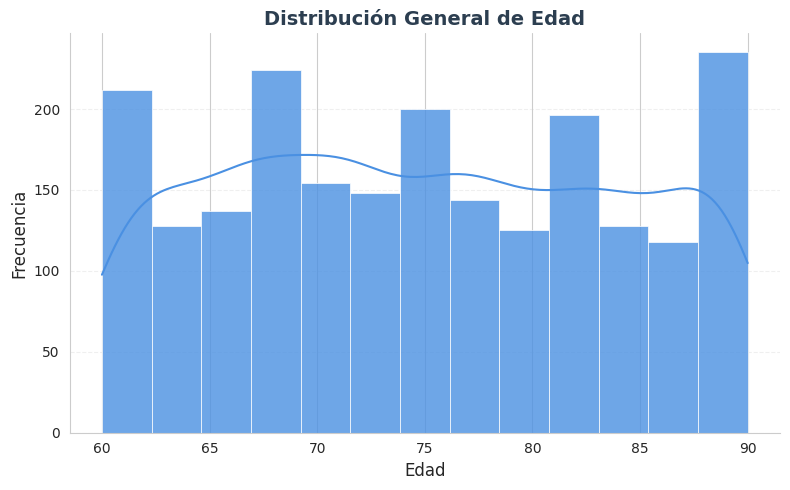

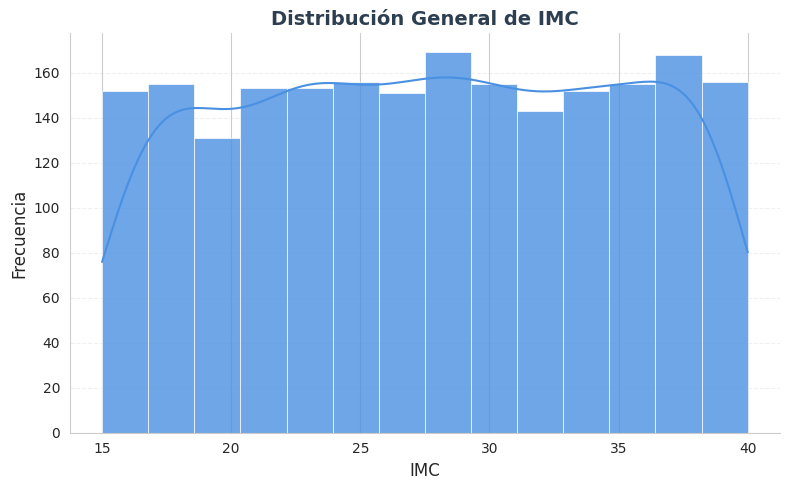

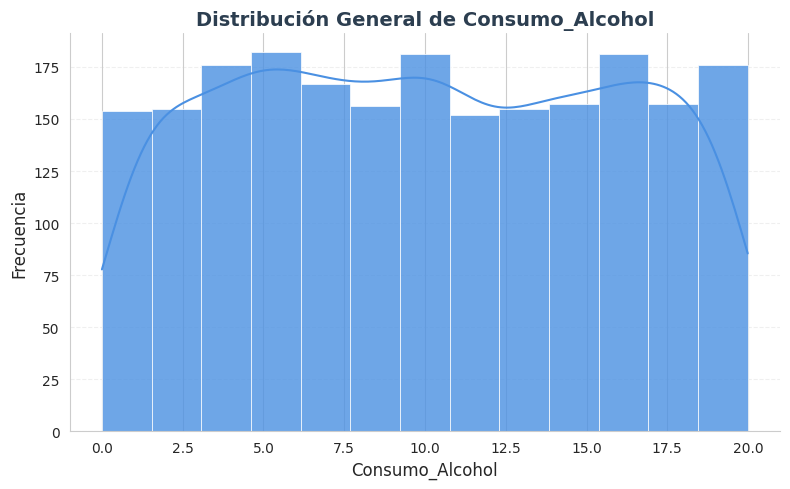

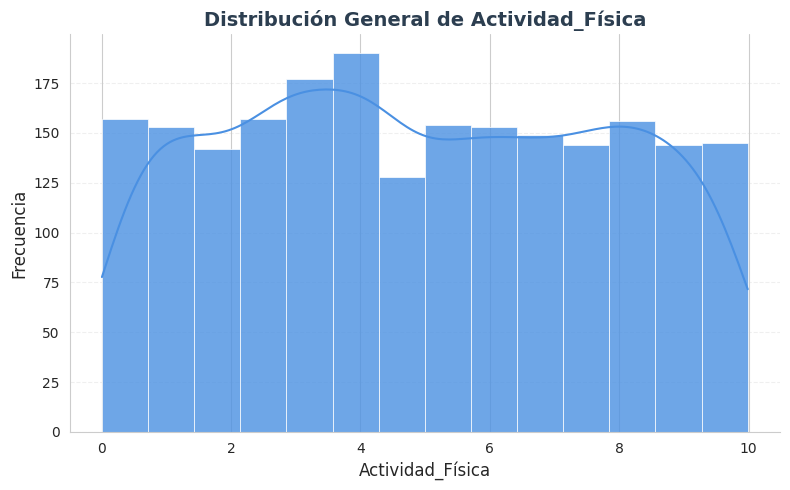

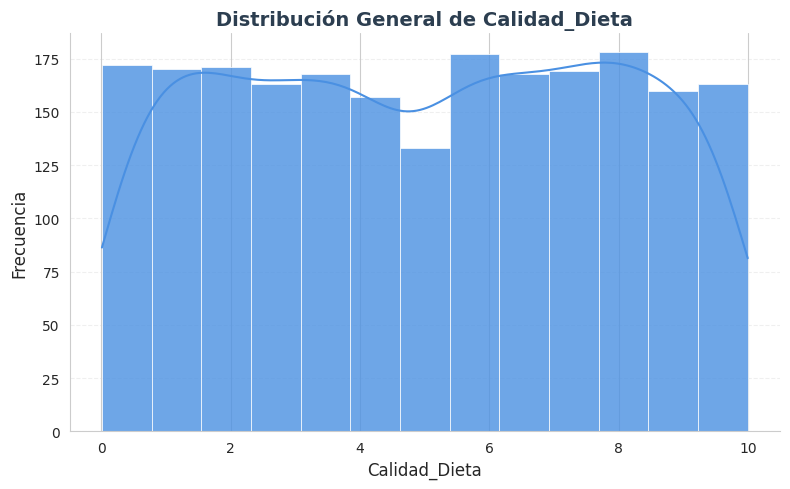

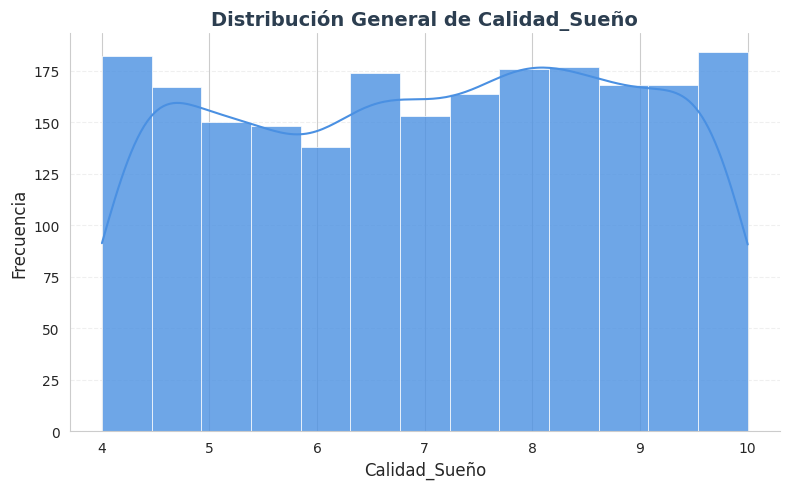

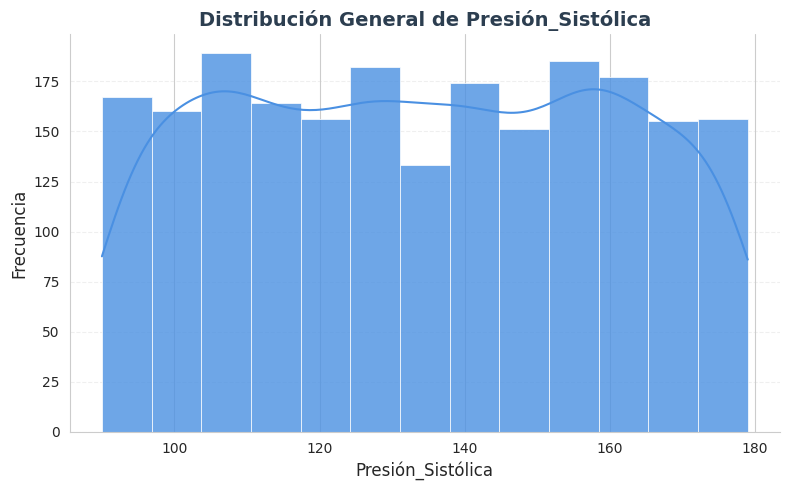

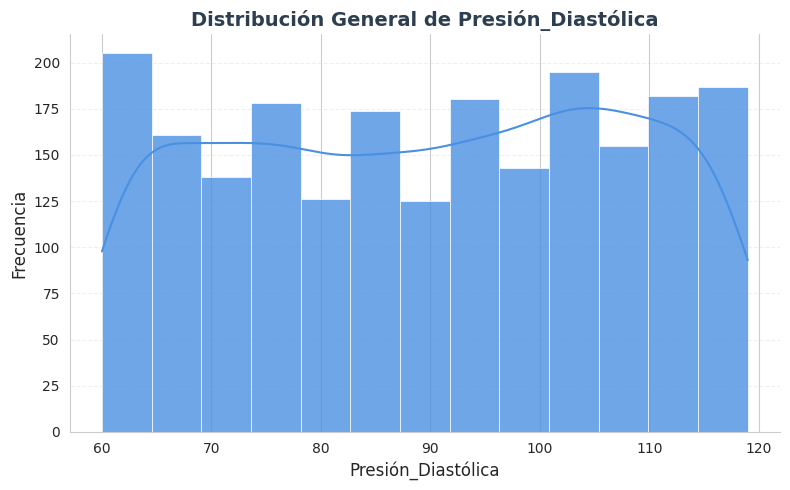

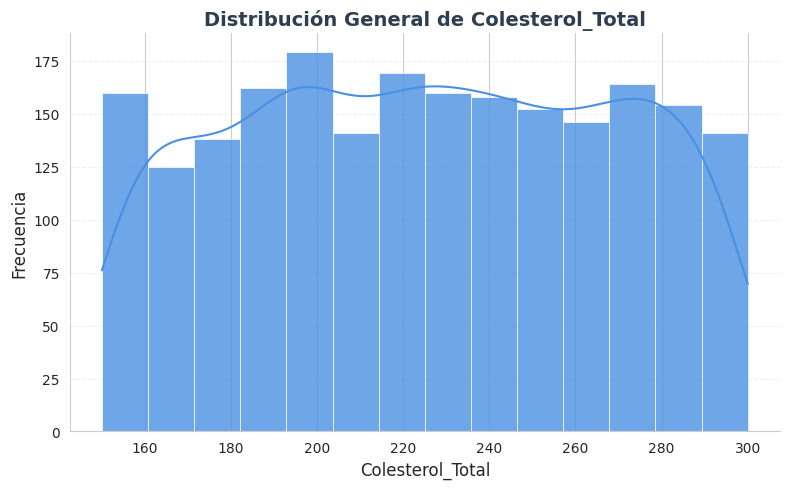

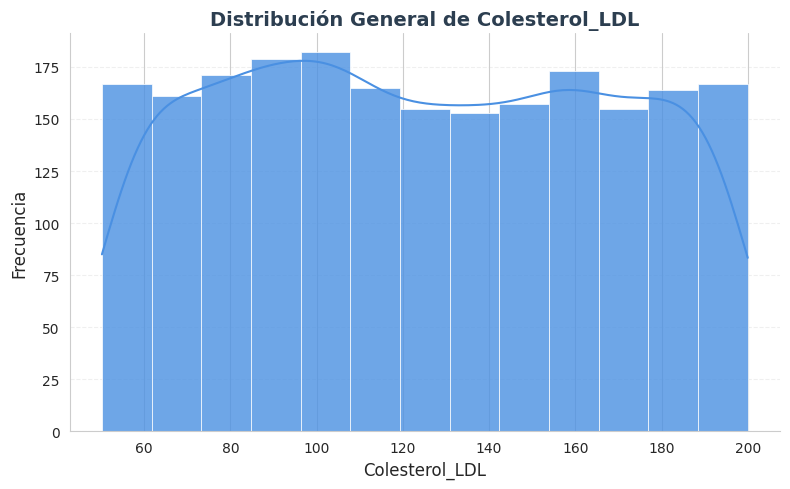

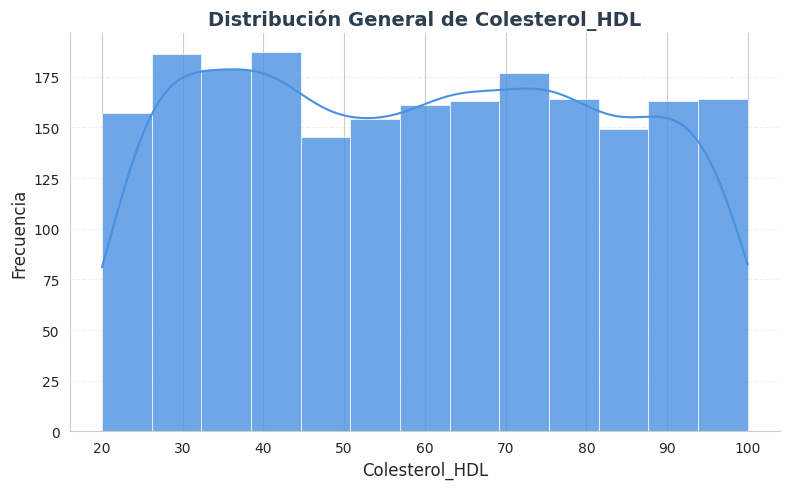

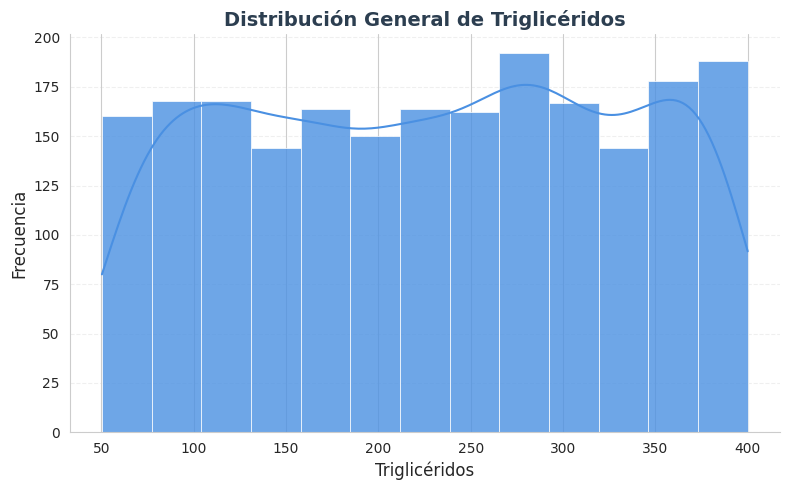

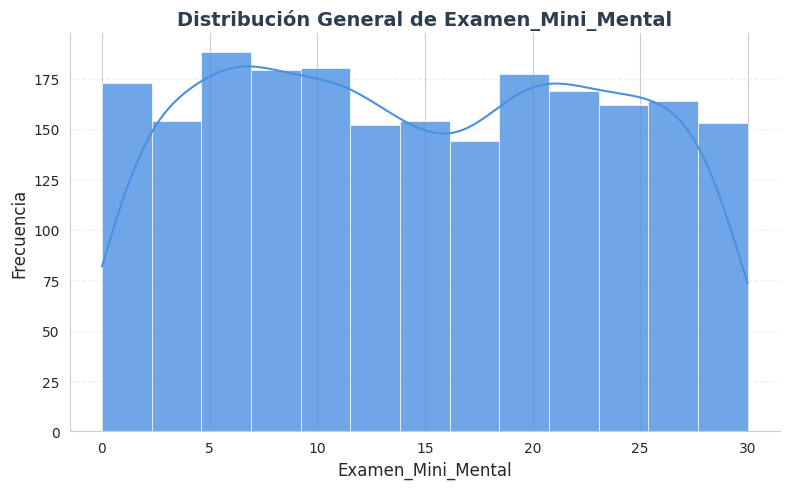

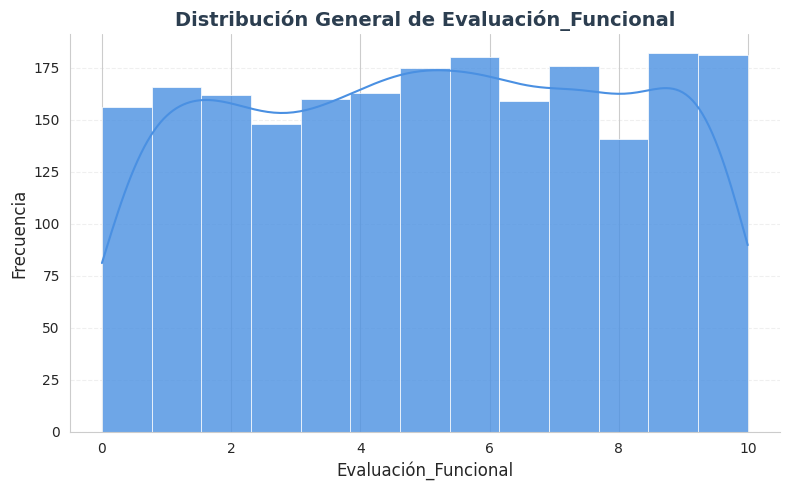

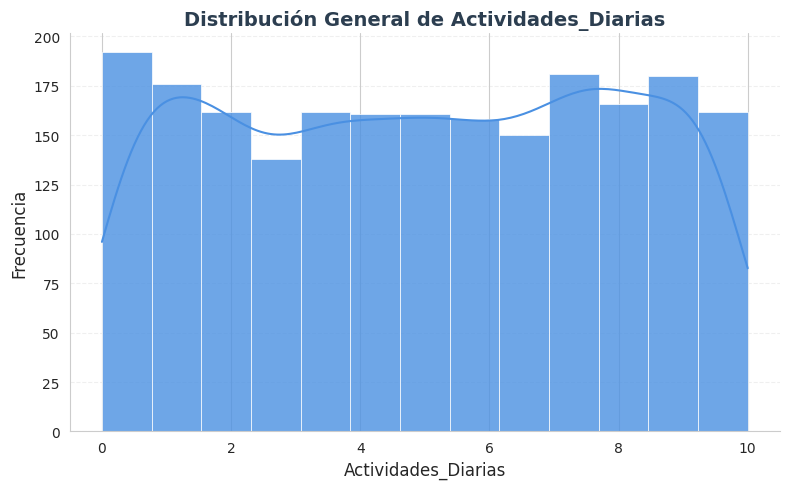

In [ ]:
# Definimos las variables numéricas
variables_numericas = [
    'Edad', 'IMC', 'Consumo_Alcohol', 'Actividad_Física', 'Calidad_Dieta',
    'Calidad_Sueño', 'Presión_Sistólica', 'Presión_Diastólica',
    'Colesterol_Total', 'Colesterol_LDL', 'Colesterol_HDL', 'Triglicéridos',
    'Examen_Mini_Mental', 'Evaluación_Funcional', 'Actividades_Diarias'
]

# 1. Configuración de estilo (Evitar repetir en cada iteración)
sns.set_style("whitegrid")
color_general = '#4A90E2' # Un azul elegante y profesional

print(f"📊 Generando histogramas generales para {len(variables_numericas)} variables...\n")

# 2. Iteración limpia y eficiente
for var in variables_numericas:
    plt.figure(figsize=(8, 5))

    # Histograma simple (Sin hue, Sin segmentación)
    ax = sns.histplot(
        data=df,
        x=var,
        kde=True,             # Curva de densidad para ver la forma
        color=color_general,  # Color único
        edgecolor='white',
        linewidth=0.5,
        alpha=0.8
    )

    # 3. Estética centralizada
    ax.set_title(f'Distribución General de {var}', fontsize=14, fontweight='bold', color='#2C3E50')
    ax.set_xlabel(var, fontsize=12)
    ax.set_ylabel('Frecuencia', fontsize=12)

    # Limpieza de bordes (estilo minimalista)
    ax.spines[['top', 'right']].set_visible(False)
    ax.spines[['left', 'bottom']].set_color('#CCC')

    plt.grid(axis='y', alpha=0.3, linestyle='--')
    plt.tight_layout()
    plt.show()

#### Categoricos

📊 Generando gráficos de barras para 17 variables categóricas...



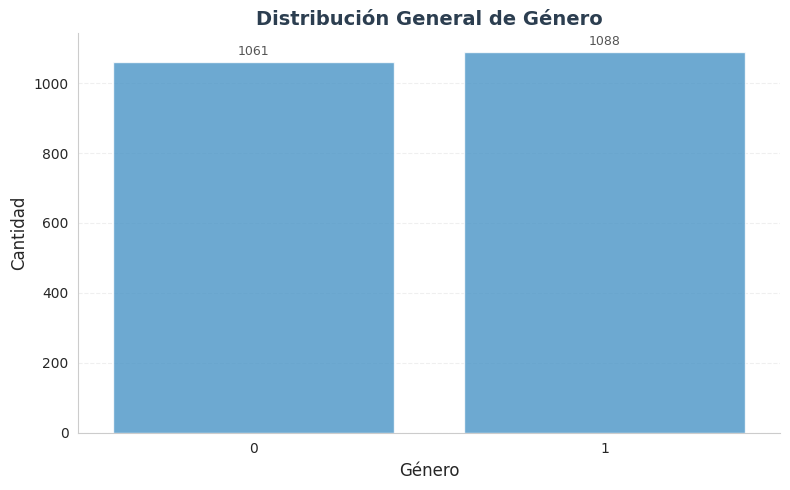

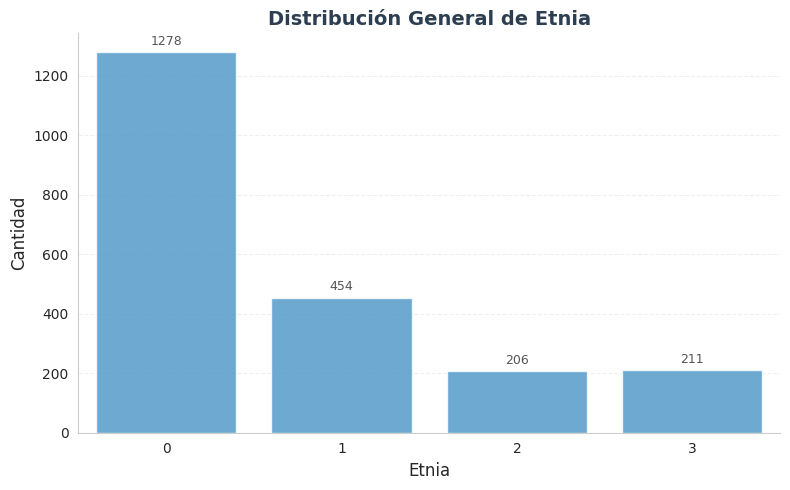

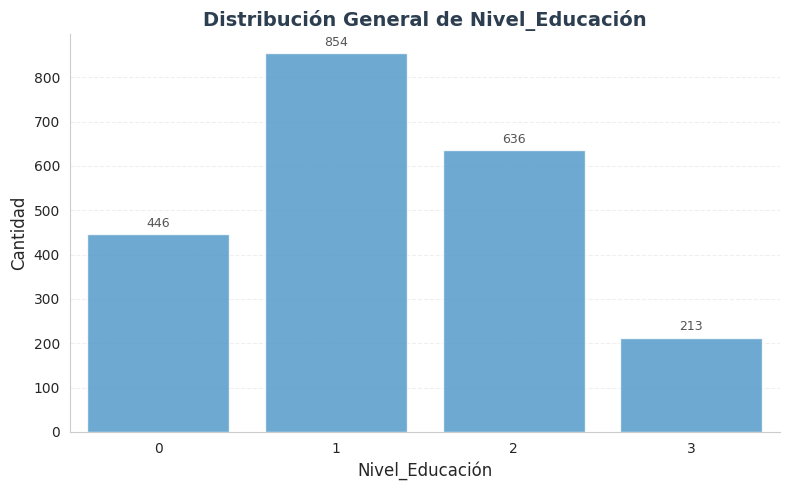

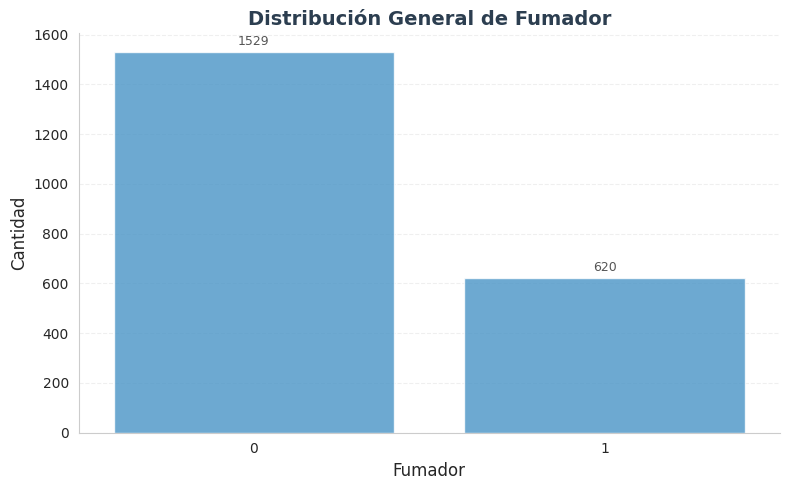

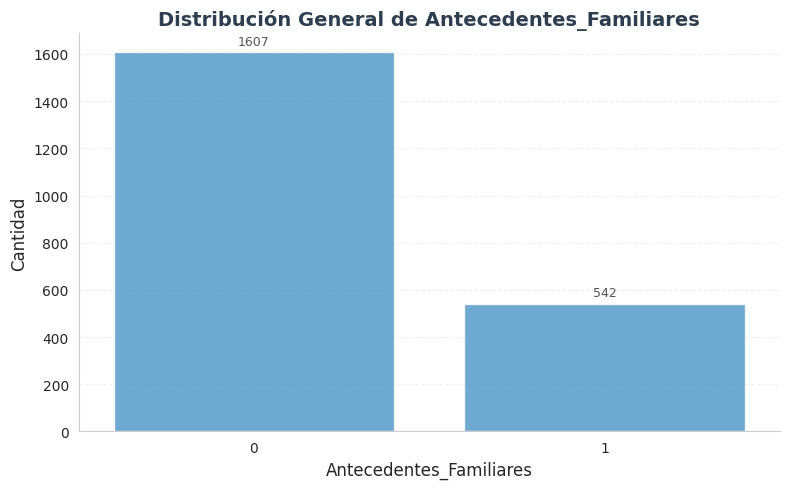

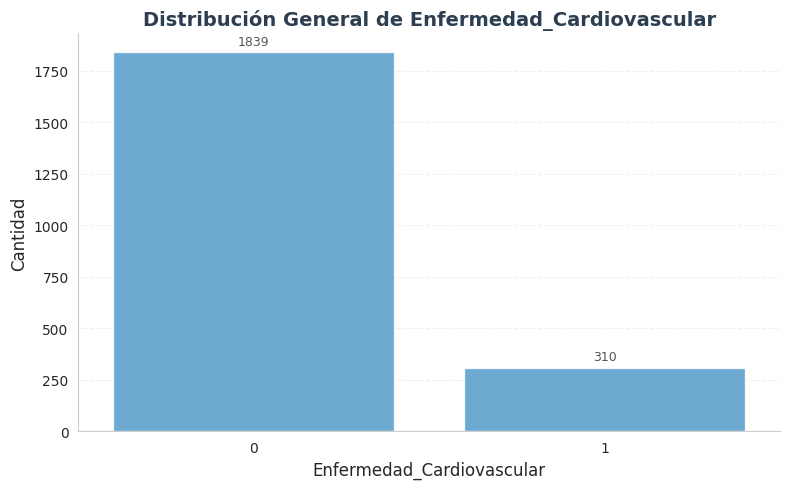

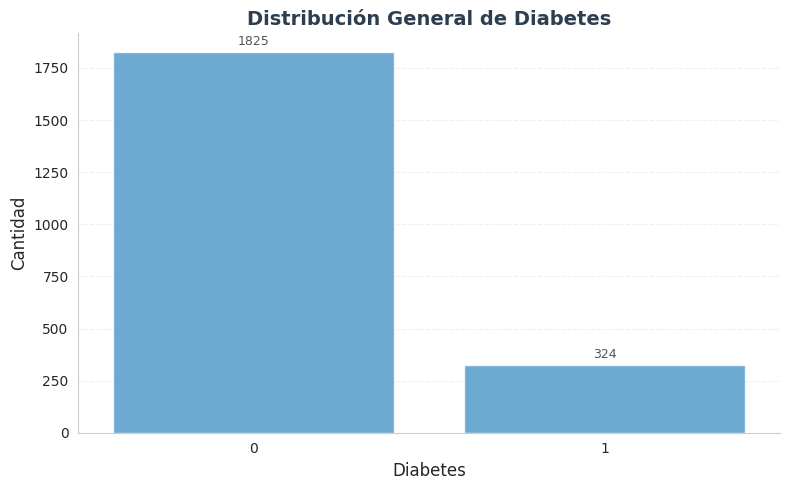

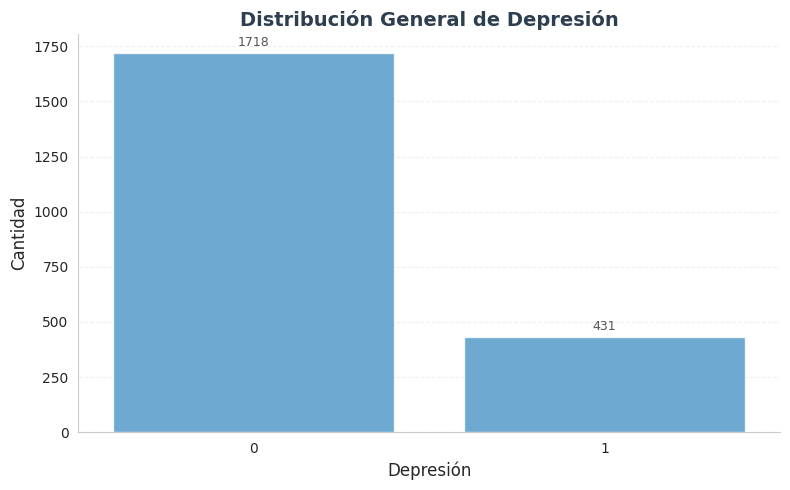

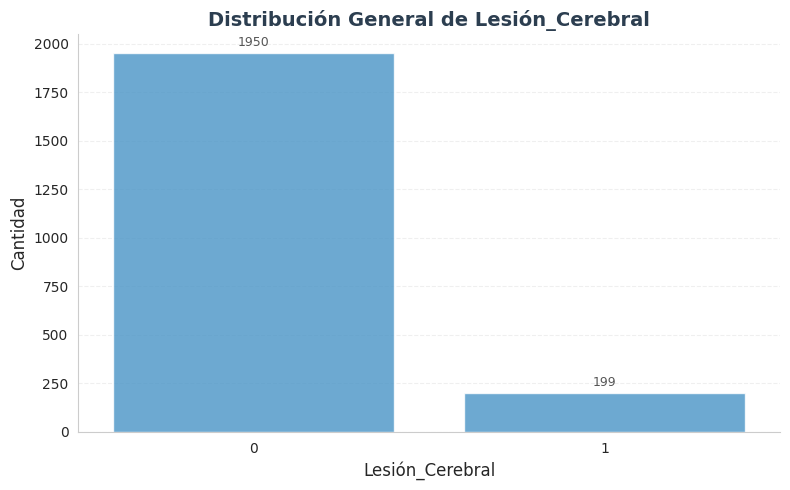

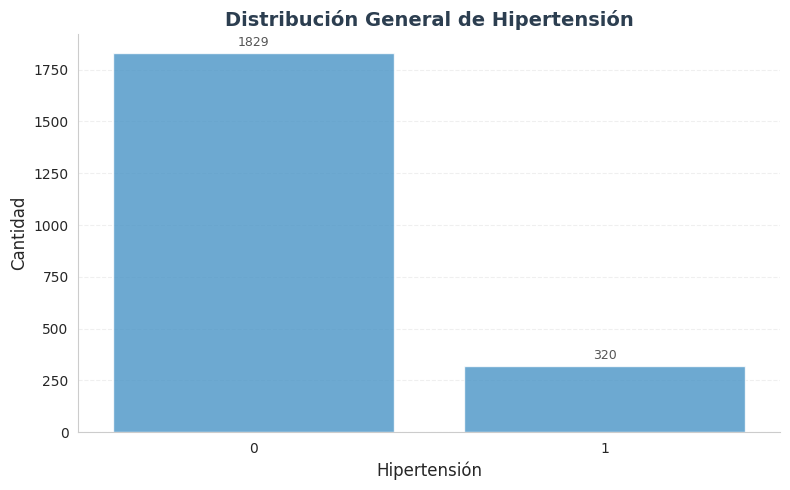

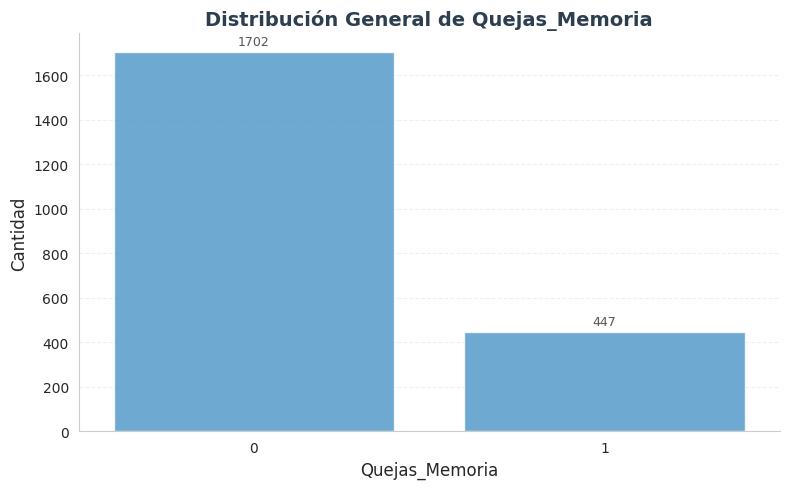

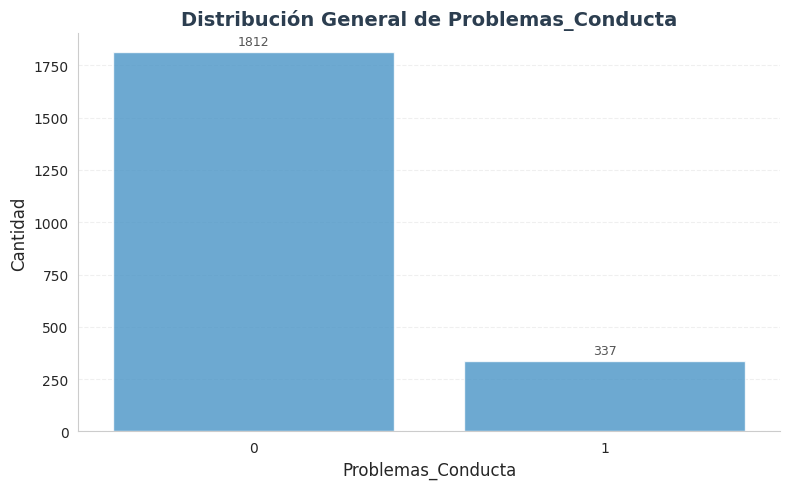

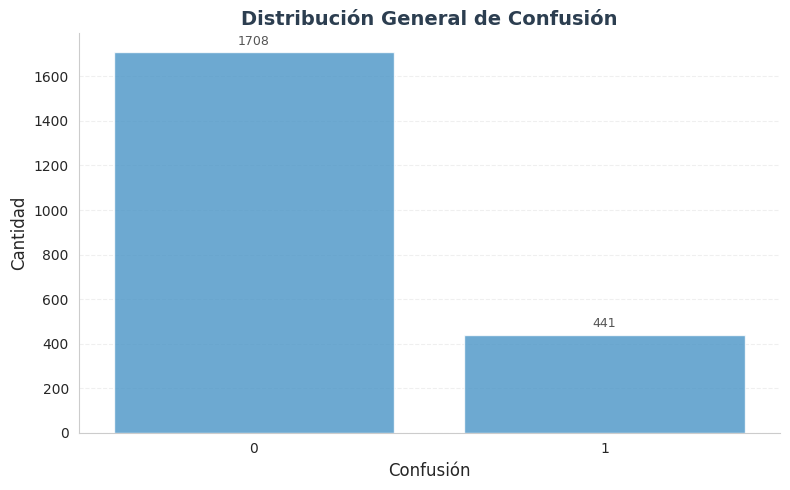

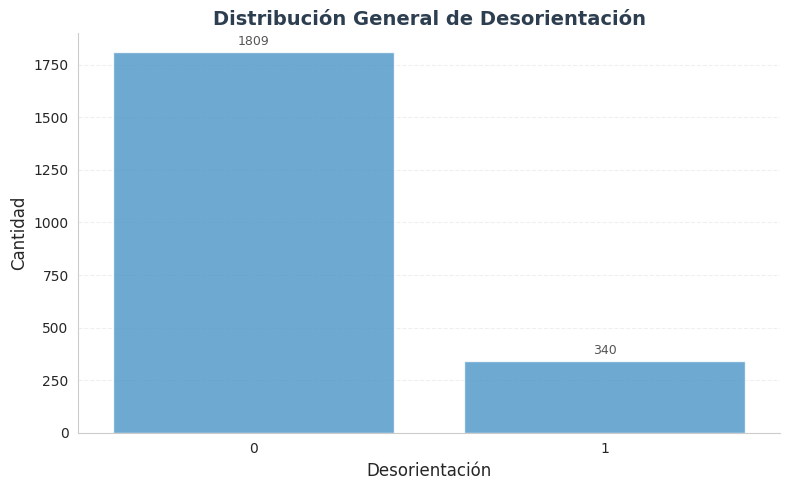

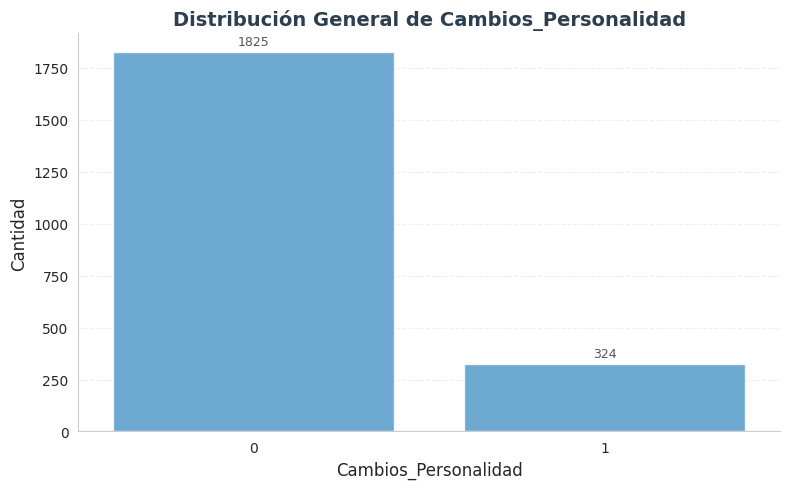

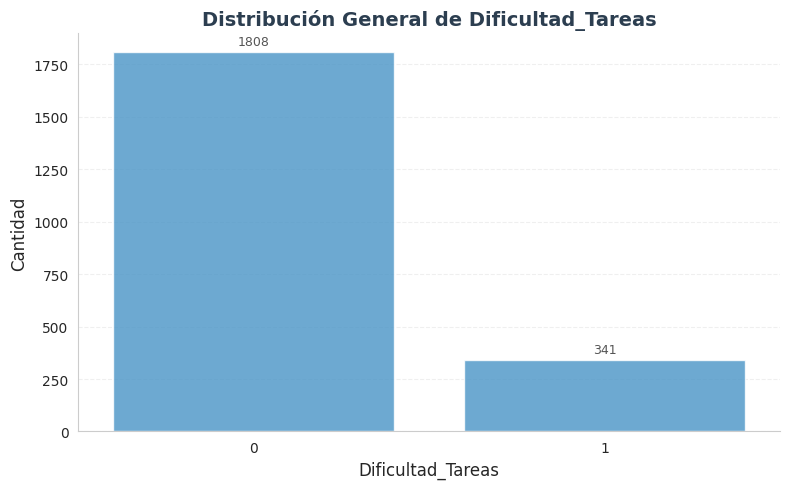

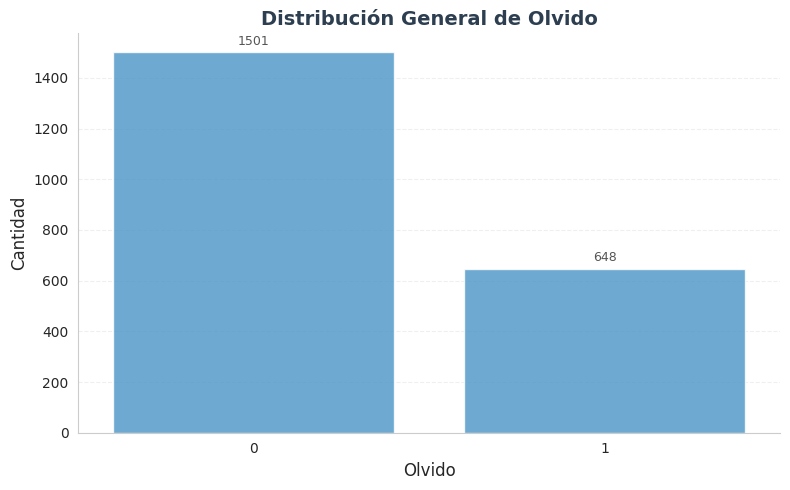

In [ ]:
# Definimos la paleta de colores del snippet (Azul para No Alzheimer, Rojo para Alzheimer)
colores_personalizados = ['#3498DB', '#E74C3C']

vars_categoricas = [
    'Género', 'Etnia', 'Nivel_Educación', 'Fumador',
    'Antecedentes_Familiares', 'Enfermedad_Cardiovascular', 'Diabetes',
    'Depresión', 'Lesión_Cerebral', 'Hipertensión', 'Quejas_Memoria',
    'Problemas_Conducta', 'Confusión', 'Desorientación',
    'Cambios_Personalidad', 'Dificultad_Tareas', 'Olvido'
]

# 1. Configuración de estilo
sns.set_style("whitegrid")
color_cat = '#3498DB' # Color único para mantener la limpieza visual

print(f"📊 Generando gráficos de barras para {len(vars_categoricas)} variables categóricas...\n")

# 2. Iteración eficiente
for var in vars_categoricas:
    plt.figure(figsize=(8, 5))

    # Usamos countplot para variables categóricas (No histplot, No KDE)
    ax = sns.countplot(
        data=df,
        x=var,
        color=color_cat,
        edgecolor='white',
        linewidth=1,
        alpha=0.8
    )

    # 3. Estética minimalista
    ax.set_title(f'Distribución General de {var}', fontsize=14, fontweight='bold', color='#2C3E50')
    ax.set_xlabel(var, fontsize=12)
    ax.set_ylabel('Cantidad', fontsize=12)

    # Limpieza de bordes
    ax.spines[['top', 'right']].set_visible(False)
    ax.spines[['left', 'bottom']].set_color('#CCC')

    # Añadir etiquetas de valor encima de las barras (Opcional pero útil en EDA)
    # Esto ayuda a ver los números exactos sin saturar
    for container in ax.containers:
        ax.bar_label(container, fmt='%d', padding=3, fontsize=9, color='#555')

    plt.grid(axis='y', alpha=0.3, linestyle='--')

    # Ajuste de etiquetas del eje X si son largas
    plt.xticks(rotation=0)

    plt.tight_layout()
    plt.show()

### Normalidad de los datos

In [ ]:
normalidad_resultados = []

for var in variables_numericas:
    stat, p = shapiro(df[var])
    normalidad_resultados.append({
        'Variable': var,
        'Estadístico': round(stat, 4),
        'p-value': round(p, 4),
        'Normal (p>0.05)': 'Sí' if p > 0.05 else 'No'
    })

df_normalidad = pd.DataFrame(normalidad_resultados)

print("🧪 Resultados del Test de Normalidad (Shapiro-Wilk):")
display(df_normalidad)

# Conclusión automática
no_normales = df_normalidad[df_normalidad['Normal (p>0.05)'] == 'No'].shape[0]
if no_normales > 0:
    print(f"\n⚠️ Conclusión: {no_normales} de {len(variables_numericas)} variables NO son normales.")
    print("➡️ Justificación: Se aplicarán métodos NO PARAMÉTRICOS en los siguientes análisis.")

🧪 Resultados del Test de Normalidad (Shapiro-Wilk):


,Variable,Estadístico,p-value,Normal (p>0.05)
0,Edad,0.9523,0.0,No
1,IMC,0.9558,0.0,No
2,Consumo_Alcohol,0.9545,0.0,No
3,Actividad_Física,0.9567,0.0,No
4,Calidad_Dieta,0.9522,0.0,No
5,Calidad_Sueño,0.9512,0.0,No
6,Presión_Sistólica,0.9551,0.0,No
7,Presión_Diastólica,0.9494,0.0,No
8,Colesterol_Total,0.9590,0.0,No
9,Colesterol_LDL,0.9536,0.0,No



⚠️ Conclusión: 15 de 15 variables NO son normales.
➡️ Justificación: Se aplicarán métodos NO PARAMÉTRICOS en los siguientes análisis.


### Correlaciones

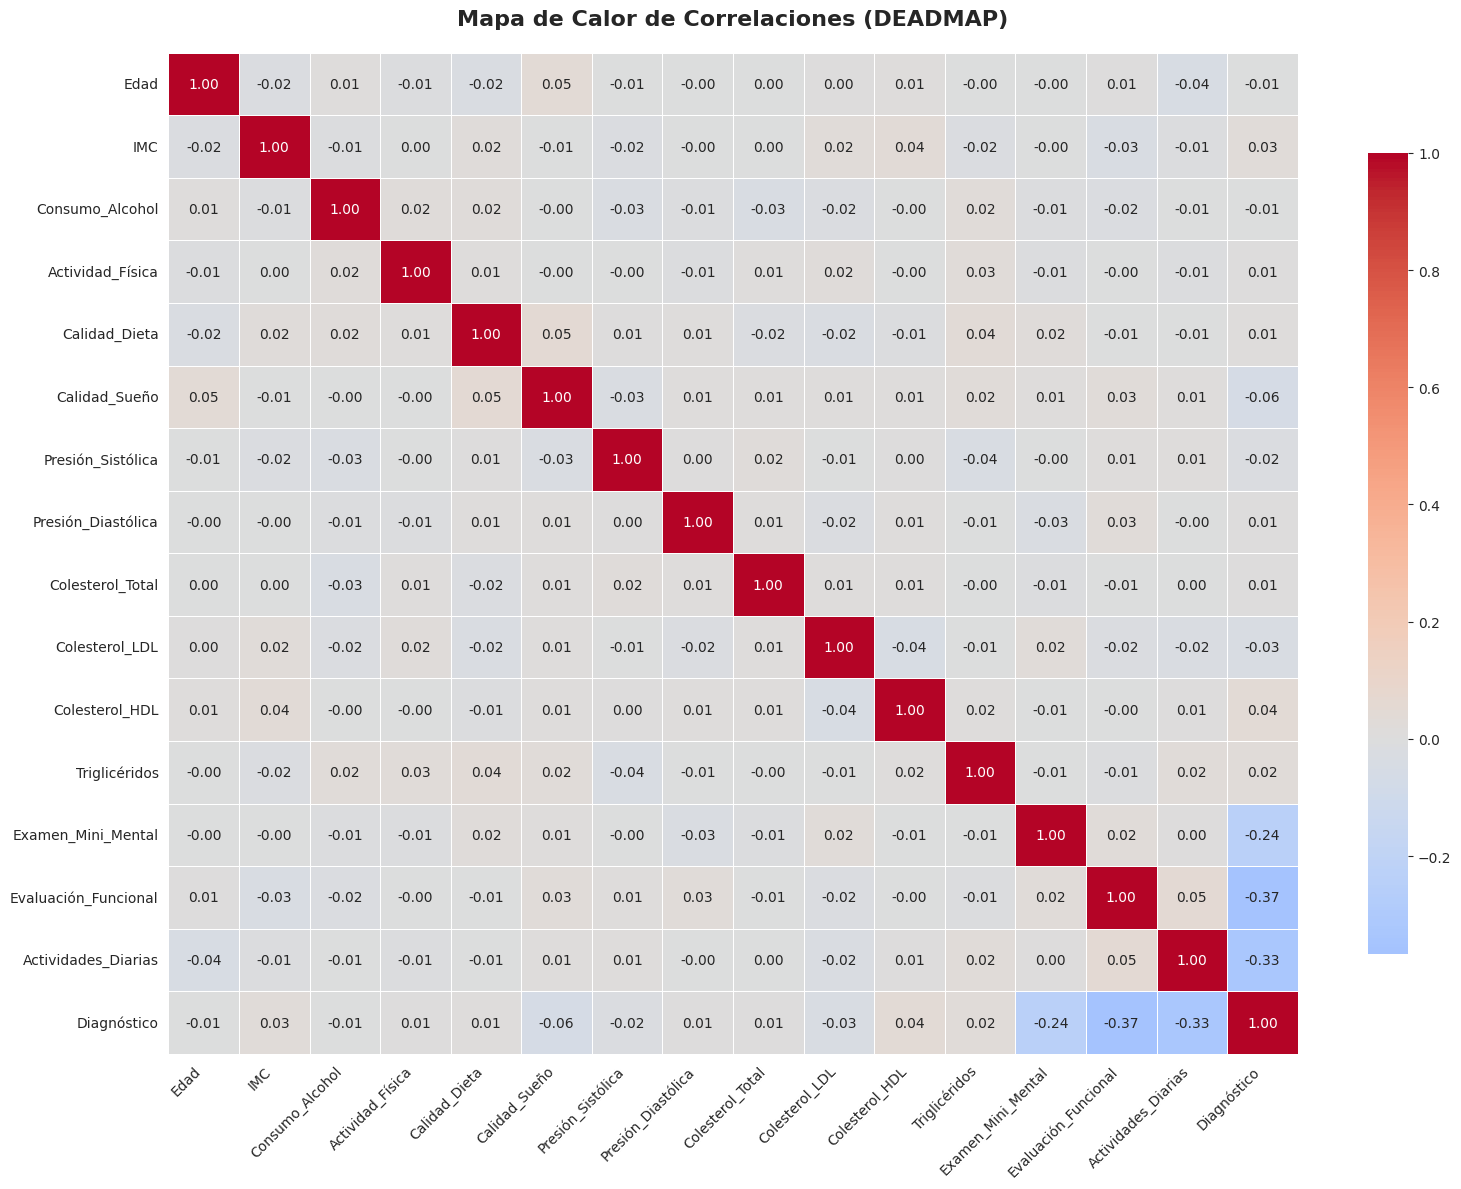

In [ ]:
# Calculamos la matriz de correlación con Spearman
corr_matrix = df[variables_numericas + ['Diagnóstico']].corr(method='spearman')

# Generamos el Heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    center=0,
    annot=True,
    fmt='.2f',
    linewidths=0.5,
    cbar_kws={'shrink': 0.8}
)
plt.title('Mapa de Calor de Correlaciones (DEADMAP)', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
# 1. Calcular matriz de correlación
corr_matrix = df[variables_numericas].corr(method='spearman') # repetido oJo

# 2. Convertir a formato largo y limpiar en un solo paso
# 'stack()' apila la matriz. Filtramos donde V1 < V2 para eliminar duplicados (A-B vs B-A) y la diagonal (A-A).
corr_pares = (
    corr_matrix.stack()
    .reset_index()
    .rename(columns={'level_0': 'Variable_1', 'level_1': 'Variable_2', 0: 'Correlación'})
)

# Truco eficiente: V1 < V2 alfabéticamente mantiene solo el triángulo superior
corr_pares = corr_pares[corr_pares['Variable_1'] < corr_pares['Variable_2']]

# 3. Ordenar por valor absoluto
corr_pares['Correlación_Abs'] = corr_pares['Correlación'].abs()
corr_pares = corr_pares.sort_values(by='Correlación_Abs', ascending=False)

# Resultados
print("📉 TOP 10 PARES DE VARIABLES MÁS CORRELACIONADAS:")
display(corr_pares.head(10).style.background_gradient(cmap='Reds', subset=['Correlación_Abs']))

# Promedio (excluyendo diagonal, que ya fue filtrada arriba)
avg_corr = corr_pares['Correlación_Abs'].mean()
print(f"\n📊 Promedio de correlación absoluta (entre pares): {avg_corr:.4f}")

📉 TOP 10 PARES DE VARIABLES MÁS CORRELACIONADAS:


,Variable_1,Variable_2,Correlación,Correlación_Abs
223,Actividades_Diarias,Evaluación_Funcional,0.053477,0.053477
65,Calidad_Dieta,Calidad_Sueño,0.051264,0.051264
75,Calidad_Sueño,Edad,0.047887,0.047887
210,Actividades_Diarias,Edad,-0.038119,0.038119
151,Colesterol_HDL,IMC,0.037960,0.037960
159,Colesterol_HDL,Colesterol_LDL,-0.037871,0.037871
101,Presión_Sistólica,Triglicéridos,-0.035488,0.035488
71,Calidad_Dieta,Triglicéridos,0.035324,0.035324
122,Colesterol_Total,Consumo_Alcohol,-0.034086,0.034086
202,Evaluación_Funcional,Presión_Diastólica,0.030950,0.030950



📊 Promedio de correlación absoluta (entre pares): 0.0144


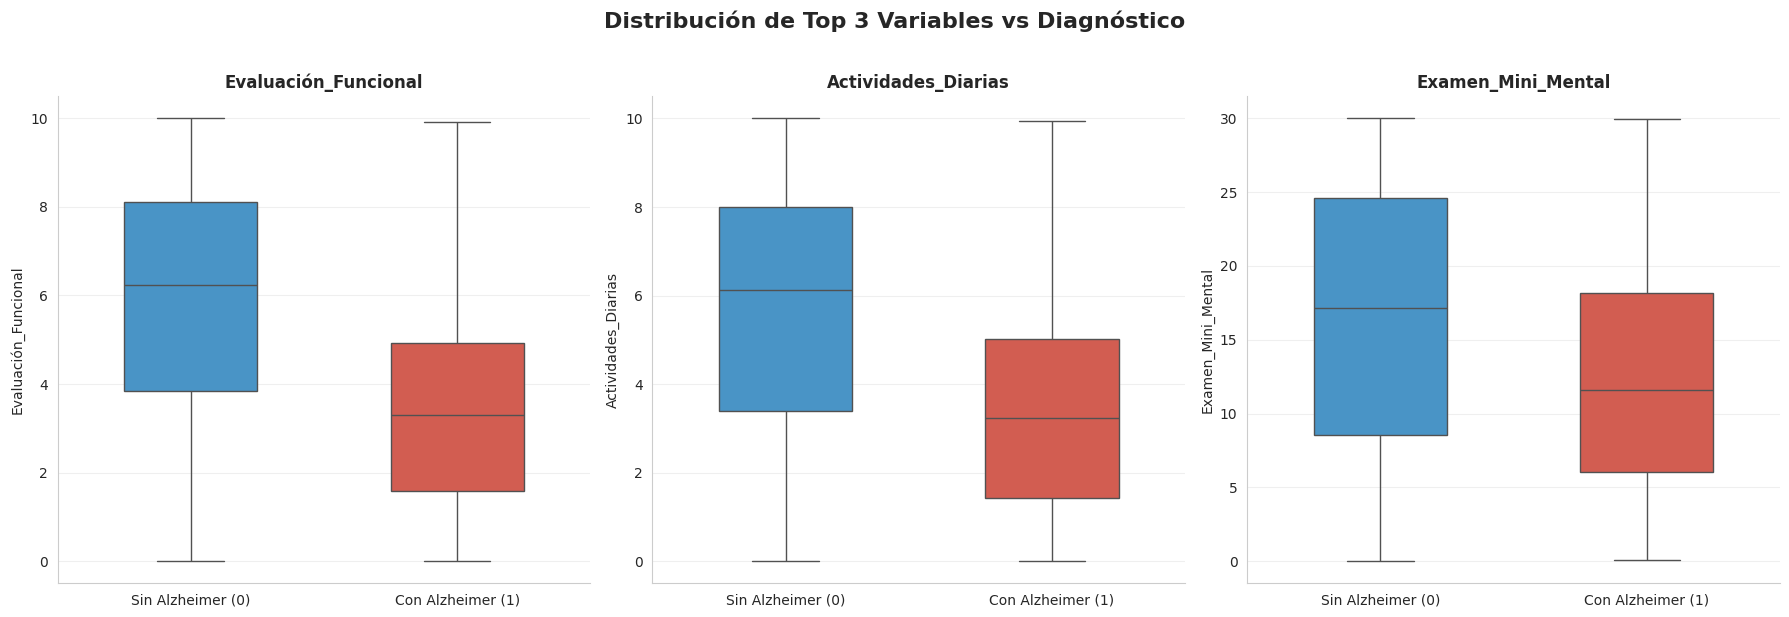

In [ ]:
# Top 3 variables identificadas en el análisis previo
top3_vars = ['Evaluación_Funcional', 'Actividades_Diarias', 'Examen_Mini_Mental']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Distribución de Top 3 Variables vs Diagnóstico', fontsize=16, fontweight='bold', y=1.02)

for i, var in enumerate(top3_vars):
    ax = axes[i]
    sns.boxplot(
        data=df,
        x='Diagnóstico',
        y=var,
        hue='Diagnóstico',
        palette=['#3498DB', '#E74C3C'],
        ax=ax,
        width=0.5,
        legend=False
    )

    # Estilo limpio
    ax.set_title(var, fontweight='bold')
    ax.set_xticklabels(['Sin Alzheimer (0)', 'Con Alzheimer (1)'])
    ax.set_xlabel('')
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
correlaciones_target = []

for var in variables_numericas:
    # Calculamos coeficiente y p-value
    coef, p = spearmanr(df[var], df['Diagnóstico'])

    correlaciones_target.append({
        'Variable': var,
        'Coef. Spearman': round(coef, 4),
        'p-value': round(p, 4),
        'Significativo (p<0.05)': 'Sí ✅' if p < 0.05 else 'No ❌'
    })

df_corr_target = pd.DataFrame(correlaciones_target).sort_values(by='Coef. Spearman', ascending=False)

print("📊 Correlación de variables numéricas vs Diagnóstico:")
display(df_corr_target)

📊 Correlación de variables numéricas vs Diagnóstico:


,Variable,Coef. Spearman,p-value,Significativo (p<0.05)
10,Colesterol_HDL,0.0425,0.0486,Sí ✅
1,IMC,0.0264,0.2212,No ❌
11,Triglicéridos,0.0231,0.2850,No ❌
4,Calidad_Dieta,0.0087,0.6879,No ❌
3,Actividad_Física,0.0059,0.7858,No ❌
8,Colesterol_Total,0.0058,0.7885,No ❌
7,Presión_Diastólica,0.0052,0.8110,No ❌
0,Edad,-0.0057,0.7906,No ❌
2,Consumo_Alcohol,-0.0086,0.6893,No ❌
6,Presión_Sistólica,-0.0158,0.4635,No ❌


Simplemente podemos ver que datos no siguen una campana de gauss perfecta, aunque se pudo visualizar en los histogramas aqui lo confirmamos con estadistica

Hipótesis

In [ ]:
hipotesis_num = []

for var in variables_numericas:
    # Separamos grupos
    grupo_sano = df[df['Diagnóstico'] == 0][var]
    grupo_alzheimer = df[df['Diagnóstico'] == 1][var]

    # Ejecutamos Mann-Whitney U
    stat, p = mannwhitneyu(grupo_sano, grupo_alzheimer, alternative='two-sided')

    hipotesis_num.append({
        'Variable': var,
        'U-Estadístico': round(stat, 2),
        'p-value': round(p, 4),
        'Diferencia Significativa': 'Sí ✅' if p < 0.05 else 'No ❌'
    })

df_mannwhitney = pd.DataFrame(hipotesis_num).sort_values(by='p-value')

print("🔬 Resultados Mann-Whitney U (Variables Numéricas):")
display(df_mannwhitney)

🔬 Resultados Mann-Whitney U (Variables Numéricas):


,Variable,U-Estadístico,p-value,Diferencia Significativa
14,Actividades_Diarias,738445.0,0.0000,Sí ✅
12,Examen_Mini_Mental,678416.0,0.0000,Sí ✅
13,Evaluación_Funcional,761542.0,0.0000,Sí ✅
5,Calidad_Sueño,563558.0,0.0094,Sí ✅
10,Colesterol_HDL,500704.0,0.0486,Sí ✅
9,Colesterol_LDL,548223.0,0.1379,No ❌
1,IMC,510992.0,0.2211,No ❌
11,Triglicéridos,513114.0,0.2849,No ❌
6,Presión_Sistólica,537904.0,0.4634,No ❌
4,Calidad_Dieta,522294.0,0.6878,No ❌


Evaluación_Funcional (-0.36): Correlación negativa fuerte.
Actividades_Diarias (-0.33): Correlación negativa fuerte.
Examen_Mini_Mental (-0.23): Correlación negativa moderada.

Podemos interpretar que si tiene menor puntaje en estas pruebas aumenta en mayor probabilidad de tener Alzheimer

In [ ]:
# Función para calcular Cramér's V
def cramers_v(confusion_matrix):
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

hipotesis_cat = []

for var in vars_categoricas:
    # Tabla de contingencia
    table = pd.crosstab(df[var], df['Diagnóstico'])

    # Chi-cuadrado
    chi2, p, dof, expected = chi2_contingency(table)

    # Cramér's V
    v = cramers_v(table.values)

    hipotesis_cat.append({
        'Variable': var,
        'Chi2-Estadístico': round(chi2, 2),
        'p-value': round(p, 4),
        'Cramér_V (Fuerza)': round(v, 4),
        'Asociación Significativa': 'Sí ✅' if p < 0.05 else 'No ❌'
    })

df_chi2 = pd.DataFrame(hipotesis_cat).sort_values(by='p-value')

print("🔬 Resultados Chi-cuadrado y Cramér's V (Variables Categóricas):")
display(df_chi2)

🔬 Resultados Chi-cuadrado y Cramér's V (Variables Categóricas):


,Variable,Chi2-Estadístico,p-value,Cramér_V (Fuerza),Asociación Significativa
10,Quejas_Memoria,200.62,0.0000,0.3049,Sí ✅
11,Problemas_Conducta,106.88,0.0000,0.2220,Sí ✅
1,Etnia,6.30,0.0978,0.0392,No ❌
9,Hipertensión,2.44,0.1181,0.0259,No ❌
4,Antecedentes_Familiares,2.17,0.1407,0.0233,No ❌
6,Diabetes,1.95,0.1622,0.0211,No ❌
5,Enfermedad_Cardiovascular,1.95,0.1628,0.0210,No ❌
2,Nivel_Educación,4.45,0.2165,0.0260,No ❌
13,Desorientación,1.17,0.2798,0.0088,No ❌
0,Género,0.86,0.3538,0.0000,No ❌


Si el paciente se queja de memoria, es muy probable que tenga Alzheimer.
Problemas de conducta tambien es muy significativa

### Distribucion de la variable objetivo

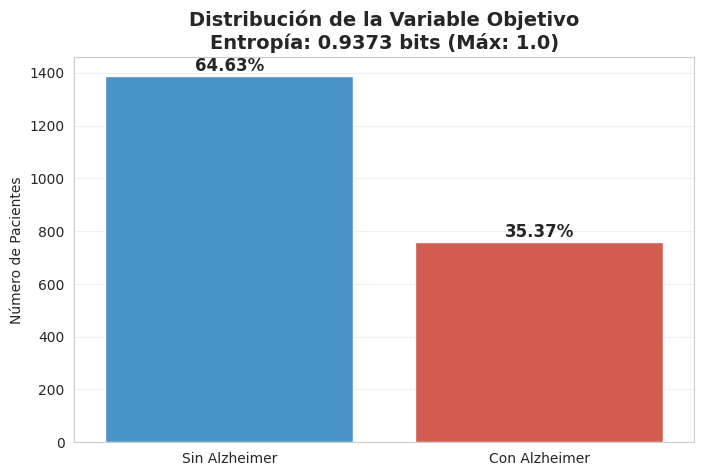

📊 ANÁLISIS DE BALANCE (Total: 2149 muestras)
----------------------------------------
Clase 0 (Sin Alzheimer): 1389 muestras (64.63%)
Clase 1 (Con Alzheimer): 760 muestras (35.37%)

📉 ENTROPÍA: 0.9373 bits (Máx: 1.0)


In [ ]:
# 1. Cálculos directos
target = 'Diagnóstico'
counts = df[target].value_counts().sort_index() # Ordenamos 0, 1 para consistencia visual
total = len(df)
probs = counts / total
entropy_val = entropy(probs, base=2)

# Mapeo de etiquetas
labels_map = {0: 'Sin Alzheimer', 1: 'Con Alzheimer'}
labels = [labels_map[i] for i in counts.index]
percents = (probs * 100).round(2)

# 2. Visualización
plt.figure(figsize=(8, 5))
ax = sns.barplot(x=labels, y=counts.values, palette=['#3498DB', '#E74C3C'])

# Añadir etiquetas de forma vectorizada
for i, (v, p) in enumerate(zip(counts.values, percents)):
    ax.text(i, v + 20, f'{p:.2f}%', ha='center', fontweight='bold', fontsize=12)

plt.title(f'Distribución de la Variable Objetivo\nEntropía: {entropy_val:.4f} bits (Máx: 1.0)',
          fontsize=14, fontweight='bold')
plt.ylabel('Número de Pacientes')
plt.grid(axis='y', alpha=0.3)
plt.show()

# 3. Reporte Impreso simplificado
print(f"📊 ANÁLISIS DE BALANCE (Total: {total} muestras)")
print("-" * 40)
for i in counts.index:
    print(f"Clase {i} ({labels_map[i]}): {counts[i]} muestras ({probs[i]*100:.2f}%)")

print(f"\n📉 ENTROPÍA: {entropy_val:.4f} bits (Máx: 1.0)")

Se observa que si bien el dataset esta medianamente desbalanceado podriamos estar peor asi que podemos considerar tecnicas de balanceo, por otro lado contamos con un nivel de entropia del 0.93 lo cual es bueno pero al mismo tiempo no tanto ya que tenemos que llegar a un equilibrio, claro esta que esto es teorico y desde mi punto de vista es bueno ya que el modelo esta forzado/obligado a aprender y no puede dar respuestas al azar ya que fallara mucho

In [ ]:
from sklearn.feature_selection import mutual_info_classif
# Preparamos los datos (llenar nulos si hubiera, aunque no los hay en este dataset sintético)
X = df[variables_numericas].fillna(0)
y = df['Diagnóstico']

# Calculamos Información Mutua (en bits, base 2)
# El parámetro 'discrete_outputs' no es válido para mutual_info_classif.
# Si las variables numéricas fueran discretas (enteros que representan categorías), se usaría 'discrete_features'.
# Como las variables son continuas (o así se tratan por defecto si no se especifica 'discrete_features'),
# mutual_info_classif las discretizará internamente para el cálculo.
mi_scores = mutual_info_classif(X, y, random_state=42)
mi_scores = pd.Series(mi_scores, index=variables_numericas).sort_values(ascending=False)

# Nivel promedio de "Entropía Compartida" (Información Mutua Promedio)
avg_mi = mi_scores.mean()

print("📉 NIVEL DE ENTROPÍA (INFORMACIÓN MUTUA)")
print("-" * 50)
print(f"Promedio de Información Mutua: {avg_mi:.4f} bits")
if avg_mi > 0.1:
    print("✅ Interpretación: Las variables contienen información relevante sobre el target.")
else:
    print("⚠️ Interpretación: Las variables aportan poca información individualmente.")

print("\n📊 Tabla de Información Mutua por Variable:")
mi_df = mi_scores.reset_index()
mi_df.columns = ['Variable', 'Mutual_Info_Score']
display(mi_df)


📉 NIVEL DE ENTROPÍA (INFORMACIÓN MUTUA)
--------------------------------------------------
Promedio de Información Mutua: 0.0202 bits
⚠️ Interpretación: Las variables aportan poca información individualmente.

📊 Tabla de Información Mutua por Variable:


,Variable,Mutual_Info_Score
0,Evaluación_Funcional,0.095454
1,Actividades_Diarias,0.076564
2,Examen_Mini_Mental,0.066278
3,Consumo_Alcohol,0.017780
4,Colesterol_HDL,0.017349
5,Calidad_Sueño,0.009691
6,Actividad_Física,0.007947
7,Edad,0.005975
8,Presión_Sistólica,0.005746
9,Colesterol_Total,0.000338


Top 3 Variables según Información Mutua: ['Evaluación_Funcional', 'Actividades_Diarias', 'Examen_Mini_Mental']


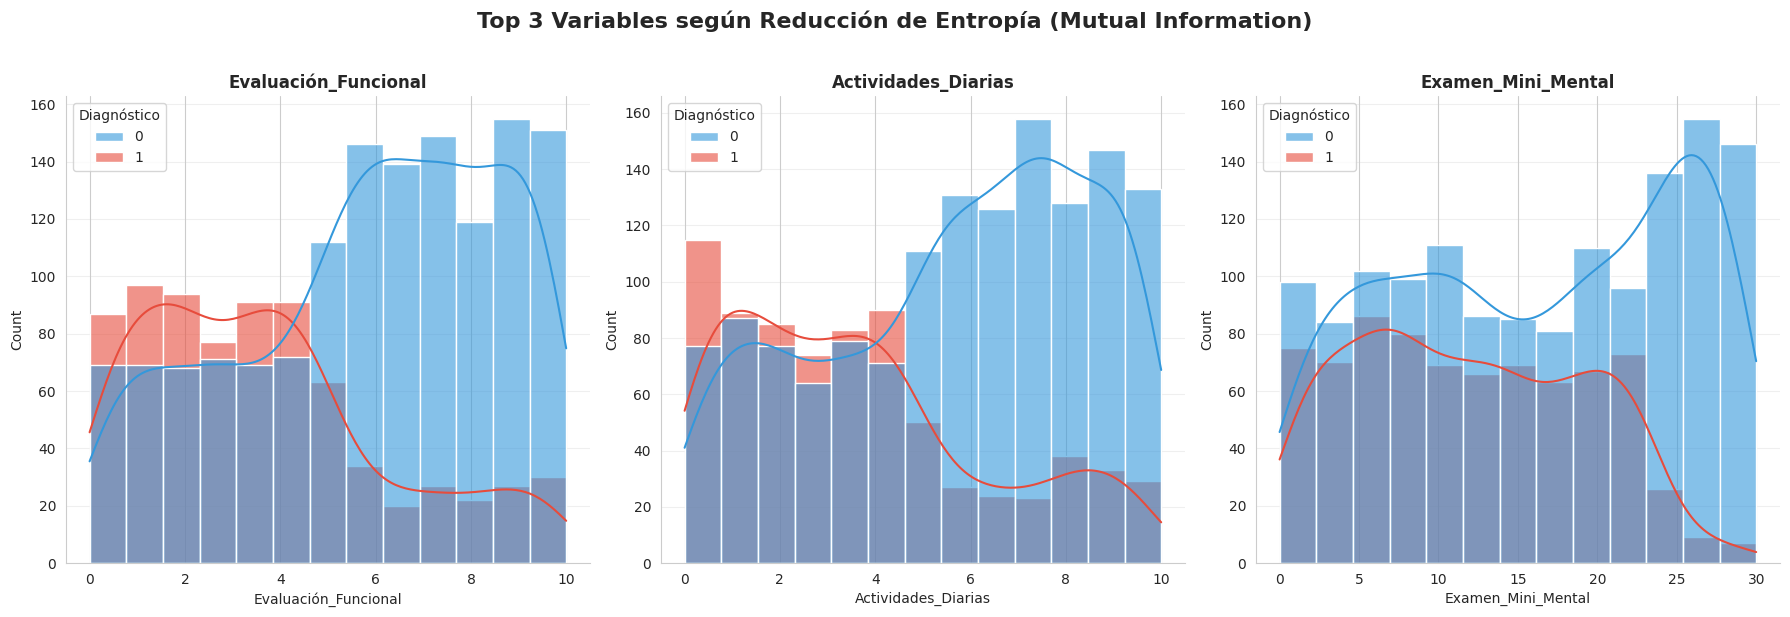

In [ ]:
# Seleccionamos el Top 3 según el cálculo de MI anterior
top3_mi_vars = mi_scores.head(3).index.tolist()

print(f"Top 3 Variables según Información Mutua: {top3_mi_vars}")

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Top 3 Variables según Reducción de Entropía (Mutual Information)', fontsize=16, fontweight='bold', y=1.02)

for i, var in enumerate(top3_mi_vars):
    ax = axes[i]
    # Usamos histogramas apilados para ver cómo "separan" la clase
    sns.histplot(
        data=df,
        x=var,
        hue='Diagnóstico',
        palette=['#3498DB', '#E74C3C'],
        ax=ax,
        kde=True,
        alpha=0.6,
        edgecolor='white'
    )
    ax.set_title(var, fontweight='bold')
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### Outliers

📊 DETECCIÓN DE OUTLIERS (Método IQR)
---------------------------------------------


,Cantidad_Outliers,Porcentaje


✅ Conclusión: No se detectaron outliers estadísticos significativos.


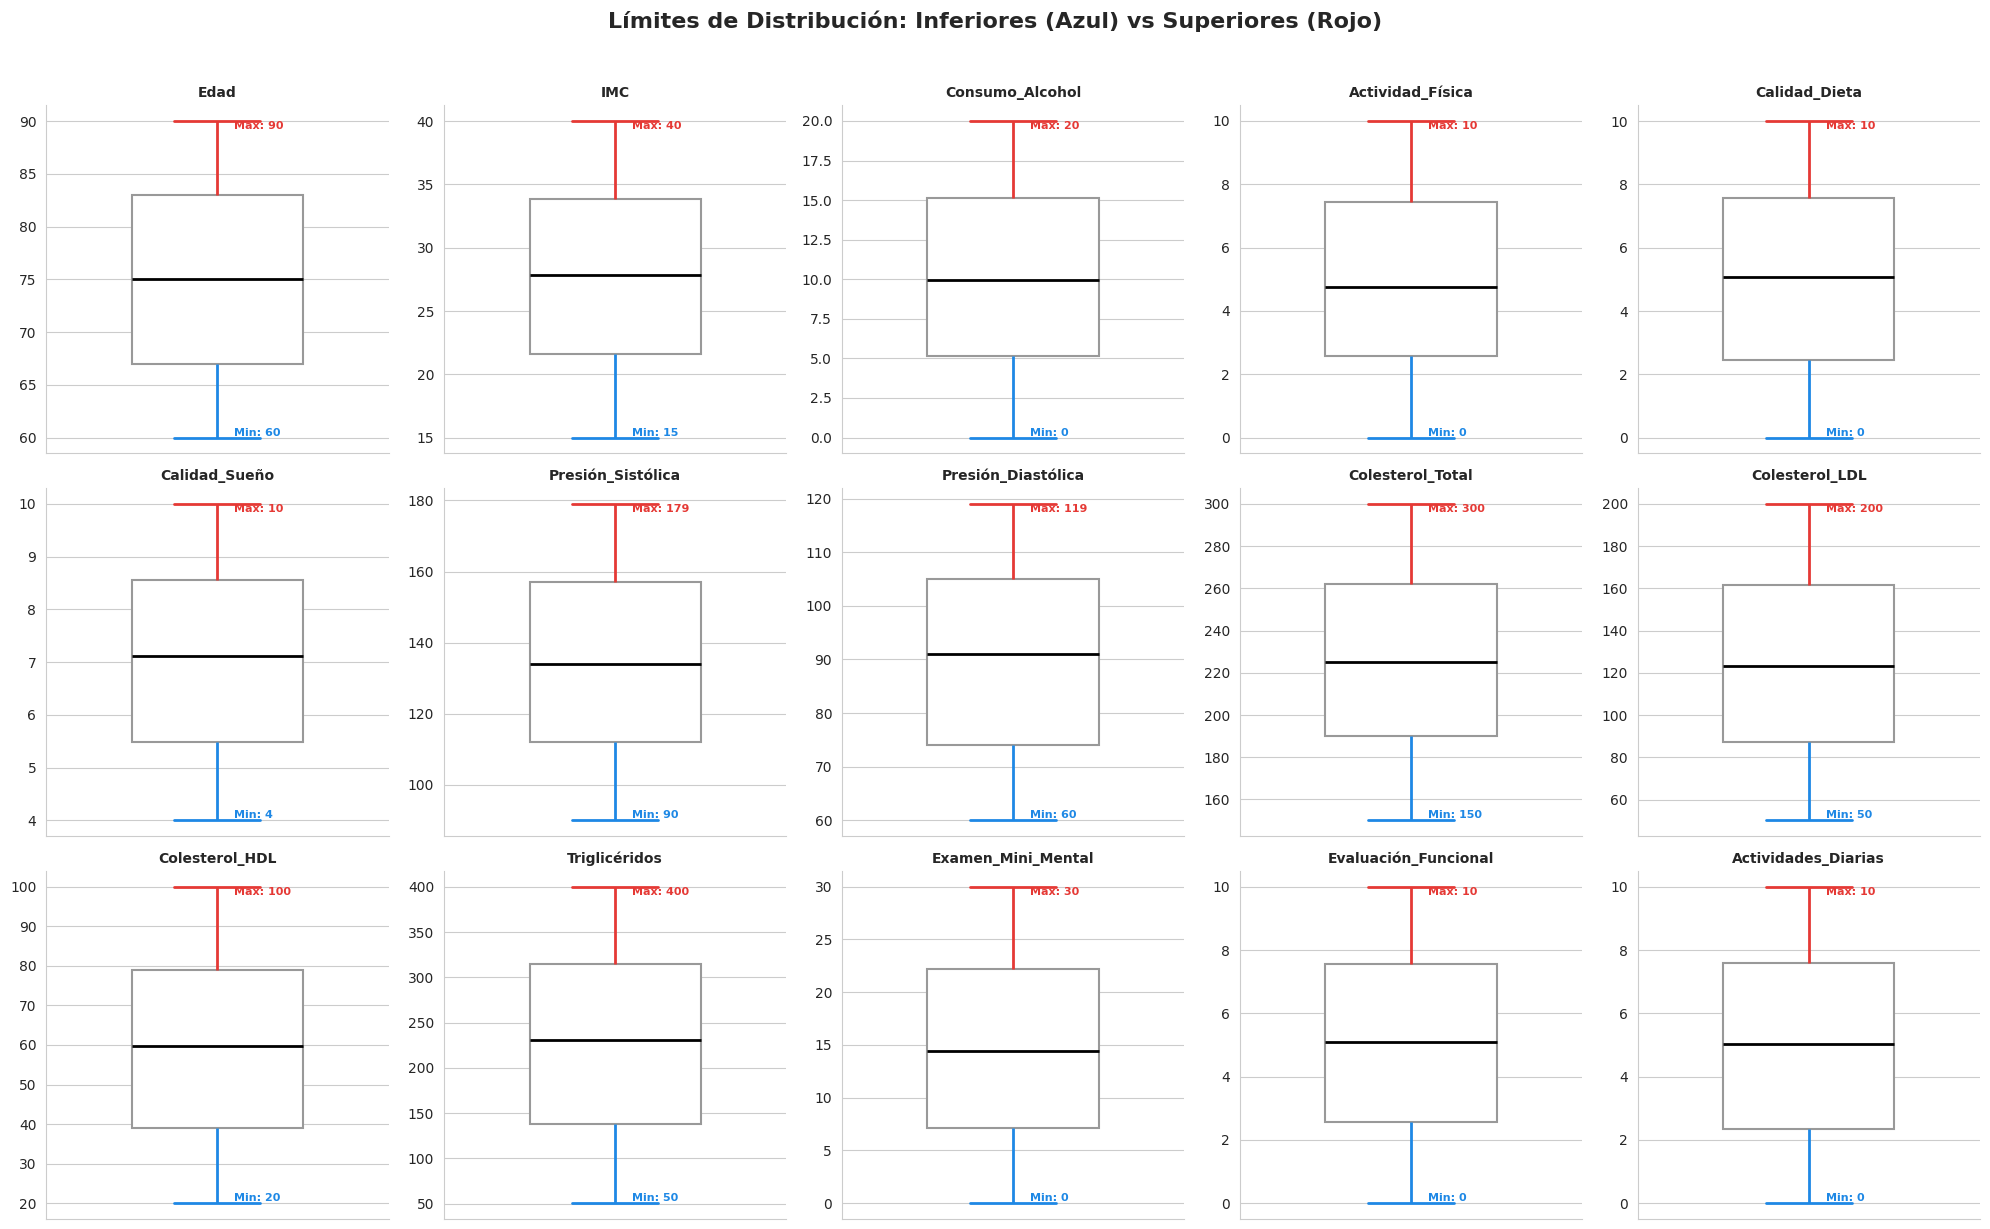

In [ ]:
# 1. Detección Matemática (IQR) - Se mantiene igual
outliers_count = {}
for col in variables_numericas:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    outliers = df[(df[col] < limite_inferior) | (df[col] > limite_superior)]
    outliers_count[col] = len(outliers)

df_outliers = pd.DataFrame.from_dict(outliers_count, orient='index', columns=['Cantidad_Outliers'])
df_outliers['Porcentaje'] = (df_outliers['Cantidad_Outliers'] / len(df)) * 100
df_outliers = df_outliers.sort_values(by='Cantidad_Outliers', ascending=False)

print("📊 DETECCIÓN DE OUTLIERS (Método IQR)")
print("-" * 45)
display(df_outliers[df_outliers['Cantidad_Outliers'] > 0])
if df_outliers['Cantidad_Outliers'].sum() == 0:
    print("✅ Conclusión: No se detectaron outliers estadísticos significativos.")

# 2. Visualización (Boxplots) con Límites Coloreados
n_cols = 5
n_rows = math.ceil(len(variables_numericas) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
axes = axes.flatten()

# Iteramos sobre cada variable y eje
for i, col in enumerate(variables_numericas):
    ax = axes[i]

    # Dibujamos el boxplot base con color neutro (caja blanca)
    sns.boxplot(y=df[col], ax=ax, color='white', linewidth=1.5,
                width=0.5, flierprops={'marker': 'o', 'markerfacecolor': 'gray', 'markersize': 3})

    # Obtenemos los valores estadísticos para colorear manualmente
    mediana = df[col].median()
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    min_val = df[col].min()
    max_val = df[col].max()

    # Colores definidos
    color_azul = '#1E88E5' # Azul impactante
    color_rojo = '#E53935' # Rojo impactante

    # Recorremos las líneas del gráfico para colorearlas
    # Los boxplots de matplotlib/seaborn están hechos de 6 líneas principales (bigotes, tapas, mediana) y el cuerpo
    # Usaremos una lógica posicional para asignar colores

    for line in ax.lines:
        # Obtener coordenadas de la línea
        xdata, ydata = line.get_xdata(), line.get_ydata()

        # 1. Mediana (línea central horizontal)
        # Su Y es la mediana
        if len(ydata) > 0 and ydata[0] == mediana:
            line.set_color('black')
            line.set_linewidth(2)

        # 2. Límite Inferior (Bigote y Tapa inferior)
        # El máximo Y del bigote inferior es Q1, el mínimo es Min
        elif len(ydata) > 0 and max(ydata) <= q1:
            line.set_color(color_azul)
            line.set_linewidth(2)

        # 3. Límite Superior (Bigote y Tapa superior)
        # El mínimo Y del bigote superior es Q3, el máximo es Max
        elif len(ydata) > 0 and min(ydata) >= q3:
            line.set_color(color_rojo)
            line.set_linewidth(2)

        # 4. Outliers (si los hubiera) - Puntos sueltos
        # No siempre se grafican como 'lines' en el iterador dependiendo la versión, pero si aparecen:
        elif len(ydata) == 1:
             line.set_markerfacecolor('gray')
             line.set_markeredgecolor('black')

    # Estética del subplot
    ax.set_title(col, fontsize=10, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.spines[['top', 'right']].set_visible(False)

    # Añadimos texto manual para los límites (opcional, para más claridad)
    ax.text(0.05, min_val, f'Min: {min_val:.0f}', color=color_azul, fontweight='bold', fontsize=8, va='bottom')
    ax.text(0.05, max_val, f'Max: {max_val:.0f}', color=color_rojo, fontweight='bold', fontsize=8, va='top')

# Ocultar ejes vacíos
for i in range(len(variables_numericas), len(axes)):
    fig.delaxes(axes[i])

plt.suptitle('Límites de Distribución: Inferiores (Azul) vs Superiores (Rojo)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# 3. Preprocesamiento

In [ ]:
# --- 1. Selección de Variables Justificada ---
# Basado en los p-values < 0.05 obtenidos en los tests Mann-Whitney y Chi² (Sección 2)

features_significativos = [
    'Evaluación_Funcional', 'Actividades_Diarias', 'Examen_Mini_Mental',
    'Calidad_Sueño', 'Colesterol_HDL',
    'Quejas_Memoria', 'Problemas_Conducta'
]

X = df[features_significativos]
y = df['Diagnóstico']

print(f"✅ Variables seleccionadas: {len(features_significativos)}")
print(f"🚫 Variables descartadas: {len(df.columns) - len(features_significativos) - 2}")

✅ Variables seleccionadas: 7
🚫 Variables descartadas: 26


In [ ]:
# --- 2. División Estratificada ---
# 75% Train, 25% Test. Stratify=y asegura el balance de clases (Alzheimer vs Sano).

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

# Reporte conciso
print(f"📂 Total: {len(df)} | Train: {len(X_train)} ({len(X_train)/len(df):.0%}) | Test: {len(X_test)} ({len(X_test)/len(df):.0%})")
print(f"⚖️ Balance (Target=1): Original {y.mean():.2%} | Train {y_train.mean():.2%} | Test {y_test.mean():.2%}")

📂 Total: 2149 | Train: 1611 (75%) | Test: 538 (25%)
⚖️ Balance (Target=1): Original 35.37% | Train 35.38% | Test 35.32%


📏 Escalado OK | 🔵 SVM Acc: 82.71% | 📗 LogReg Acc: 83.46%


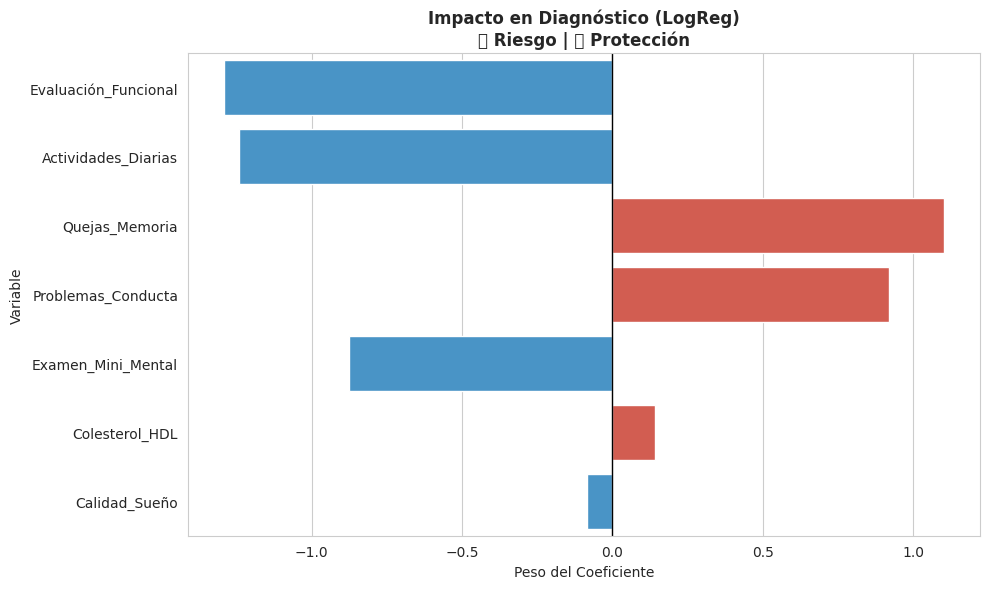


📊 Tabla de Impacto:


,Variable,Coef_LogReg,Odds_Ratio,Impacto_SVM
0,Evaluación_Funcional,-1.292,0.27,0.965236
1,Actividades_Diarias,-1.242,0.29,0.980648
5,Quejas_Memoria,+1.103,3.01,0.871256
6,Problemas_Conducta,+0.921,2.51,0.690914
2,Examen_Mini_Mental,-0.876,0.42,0.637415
4,Colesterol_HDL,+0.144,1.15,0.098444
3,Calidad_Sueño,-0.085,0.92,0.059712


In [ ]:
# --- 1. Escalado & Entrenamiento (Unificado) ---
scaler = StandardScaler()
X_train_final = pd.DataFrame(scaler.fit_transform(X_train), columns=features_significativos)
X_test_final = pd.DataFrame(scaler.transform(X_test), columns=features_significativos)

# Entrenamos ambos modelos en 2 líneas
svm = SVC(kernel='linear', C=1.0, random_state=42).fit(X_train_final, y_train)
log = LogisticRegression(max_iter=1000, random_state=42).fit(X_train_final, y_train)

print(f"📏 Escalado OK | 🔵 SVM Acc: {svm.score(X_test_final, y_test):.2%} | 📗 LogReg Acc: {log.score(X_test_final, y_test):.2%}")

# --- 2. Análisis de Coeficientes (DataFrame Unificado) ---
# Extraemos coeficientes y calculamos Odds Ratio vectorizadamente
coef_df = pd.DataFrame({
    'Variable': features_significativos,
    'Coef_LogReg': log.coef_[0],
    'Odds_Ratio': np.exp(log.coef_[0]),
    'Impacto_SVM': np.abs(svm.coef_[0]) # Magnitud en la frontera
}).sort_values('Coef_LogReg', key=abs, ascending=False)

# --- 3. Visualización Directa ---
plt.figure(figsize=(10, 6))
# Colores: Rojo si coef > 0 (Riesgo), Azul si coef < 0 (Protección)
colors = ['#E74C3C' if c > 0 else '#3498DB' for c in coef_df['Coef_LogReg']]

sns.barplot(data=coef_df, y='Variable', x='Coef_LogReg', palette=colors)
plt.title('Impacto en Diagnóstico (LogReg)\n🔴 Riesgo | 🔵 Protección', fontweight='bold')
plt.xlabel('Peso del Coeficiente')
plt.axvline(0, color='black', lw=1)
plt.tight_layout()
plt.show()

# Reporte numérico limpio
print("\n📊 Tabla de Impacto:")
display(coef_df.style.format({'Coef_LogReg': '{:+.3f}', 'Odds_Ratio': '{:.2f}'}))

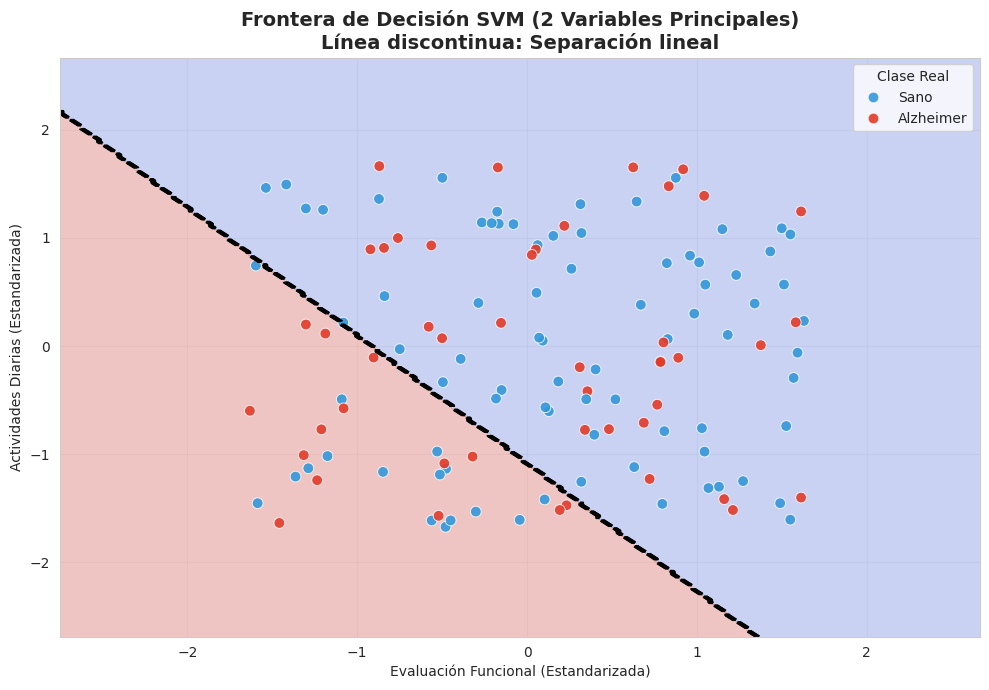

In [ ]:
# --- 0. Suprimir Warnings ---
warnings.filterwarnings('ignore')

# --- 1. Selección y Entrenamiento (2D) ---
vars_top2 = ['Evaluación_Funcional', 'Actividades_Diarias']
X_train_2d = X_train_final[vars_top2]
X_test_2d = X_test_final[vars_top2]

svm_2d = SVC(kernel='linear', C=1.0, random_state=42)
svm_2d.fit(X_train_2d, y_train)

# --- 2. Malla y Predicción (Corregido para evitar warning de sklearn) ---
x_min, x_max = X_train_2d.iloc[:, 0].min() - 1, X_train_2d.iloc[:, 0].max() + 1
y_min, y_max = X_train_2d.iloc[:, 1].min() - 1, X_train_2d.iloc[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# CORRECCIÓN: Usar DataFrame con nombres de columnas para evitar el warning
grid_df = pd.DataFrame(np.c_[xx.ravel(), yy.ravel()], columns=vars_top2)
Z = svm_2d.predict(grid_df)
Z = Z.reshape(xx.shape)

# --- 3. Visualización ---
plt.figure(figsize=(10, 7))

# Fondo (Regiones)
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')

# Línea de Frontera
plt.contour(xx, yy, Z, colors='k', linewidths=2, linestyles=['--'])

# CORRECCIÓN DE LEYENDA: Mapeamos números a nombres explícitos
# Convertimos 0 -> "Sano", 1 -> "Alzheimer" para que el gráfico lo entienda automáticamente
y_test_labels = y_test.map({0: 'Sano', 1: 'Alzheimer'})

# Definimos la paleta con NOMBRES (clave para que coincida)
palette_map = {'Sano': '#3498DB', 'Alzheimer': '#e33a29'}

sns.scatterplot(
    x=X_test_2d.iloc[:, 0],
    y=X_test_2d.iloc[:, 1],
    hue=y_test_labels,        # Usamos las etiquetas de texto
    palette=palette_map,      # Mapeamos texto -> color
    edgecolor='white',
    s=60,
    alpha=0.9
)

plt.title('Frontera de Decisión SVM (2 Variables Principales)\nLínea discontinua: Separación lineal', fontsize=14, fontweight='bold')
plt.xlabel('Evaluación Funcional (Estandarizada)')
plt.ylabel('Actividades Diarias (Estandarizada)')

plt.legend(title='Clase Real')
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

# 4. Modelado
## Modelado con validación estadística
### k-NN · Regresión Logística · SVM · Cross-validation · Curvas de aprendizaje

In [ ]:
print("🎯 Iniciando comparación de Métodos de Selección de Variables...")
print("-" * 70)

# Diccionario para guardar los resultados de cada estrategia
resultados_seleccion = {}

# Definimos el modelo base para evaluar las selecciones (puede ser cualquiera)
# Usamos un modelo rápido para la comparación de selecciones
modelo_base = LogisticRegression(max_iter=1000, random_state=42)

# --- Definición de las 6 Estrategias de Selección ---
# Las envolvemos en un diccionario: 'Nombre': (Pipeline_Step, Parámetros_Grid)

estrategias = {
    # 1. BASELINE (Sin selección)
    '1. Baseline (Sin selección)': (
        Pipeline([('model', modelo_base)]),
        {'model__C': [0.1, 1, 10]}
    ),

    # 2. FILTER (SelectKBest con ANOVA)
    '2. Filter (KBest)': (
        Pipeline([('select', SelectKBest(score_func=f_classif)), ('model', modelo_base)]),
        {'select__k': [5, 10, 15, 20], 'model__C': [0.1, 1, 10]}
    ),

    # 3. EMBEDDED (SelectFromModel usando Lasso/L1)
    '3. Embedded (Lasso L1)': (
        Pipeline([
            ('select', SelectFromModel(LogisticRegression(penalty='l1', solver='liblinear', max_iter=1000))),
            ('model', modelo_base)
        ]),
        {'select__estimator__C': [0.01, 0.1, 1], 'model__C': [0.1, 1]}
    ),

    # 4. WRAPPER (RFE - Recursive Feature Elimination)
    '4. Wrapper (RFE)': (
        Pipeline([('select', RFE(estimator=modelo_base)), ('model', modelo_base)]),
        {'select__n_features_to_select': [5, 10, 15], 'model__C': [0.1, 1]}
    ),

    # 5. STEPWISE / AIC (Sequential Forward Selection)
    # Nota: Esto es computacionalmente costoso, reduce cv si tarda mucho
    '5. Stepwise (SFS)': (
        Pipeline([('select', SequentialFeatureSelector(modelo_base, direction='forward', scoring='f1')),
                  ('model', modelo_base)]),
        {'select__n_features_to_select': [5, 10, 15], 'model__C': [0.1, 1]}
    ),

    # 6. EMBEDDED (Random Forest Importance)
    '6. Embedded (RF Importance)': (
        Pipeline([
            ('select', SelectFromModel(RandomForestClassifier(n_estimators=50, random_state=42))),
            ('model', modelo_base)
        ]),
        {'select__threshold': ['mean', 'median'], 'model__C': [0.1, 1]}
    )
}

# --- Bucle de Entrenamiento ---
for nombre, (pipeline, params) in estrategias.items():
    print(f"⚙️  Evaluando: {nombre}...")
    start = time.time()

    # GridSearchCV para optimizar tanto la selección como el modelo
    # Reducimos n_jobs a 1 si usamos SFS para evitar problemas de paralelización
    grid = GridSearchCV(pipeline, params, cv=5, scoring='f1', n_jobs=-1)
    grid.fit(X_train_final, y_train)

    resultados_seleccion[nombre] = {
        'mejor_score': grid.best_score_,
        'mejor_pipeline': grid.best_estimator_,
        'tiempo': time.time() - start
    }
    print(f"   ✅ Mejor F1 CV: {grid.best_score_:.4f} | Tiempo: {time.time()-start:.2f}s")

print("-" * 70)
print("🏆 Comparación finalizada.")

print("🔍 Iniciando búsqueda de hiperparámetros (GridSearchCV) para 5 modelos...")
print("-" * 60)

# Diccionario para guardar los mejores modelos encontrados
mejores_modelos = {}

# --- 1. k-NN ---
print("1️⃣ Optimizando k-NN...")
start = time.time()
params_knn = {'n_neighbors': list(range(1, 21, 2))} # Impares del 1 al 20
grid_knn = GridSearchCV(KNeighborsClassifier(), params_knn, cv=5, scoring='f1', n_jobs=-1)
grid_knn.fit(X_train_final, y_train)
mejores_modelos['k-NN'] = grid_knn.best_estimator_
print(f"   ✅ Mejor k: {grid_knn.best_params_['n_neighbors']} | F1 CV: {grid_knn.best_score_:.4f} | Tiempo: {time.time()-start:.2f}s")

# --- 2. Regresión Logística ---
print("2️⃣ Optimizando Regresión Logística...")
start = time.time()
params_log = {'C': [0.01, 0.1, 1, 10, 100], 'solver': ['liblinear', 'lbfgs']}
grid_log = GridSearchCV(LogisticRegression(max_iter=1000), params_log, cv=5, scoring='f1', n_jobs=-1)
grid_log.fit(X_train_final, y_train)
mejores_modelos['Regresión Logística'] = grid_log.best_estimator_
print(f"   ✅ Mejor C: {grid_log.best_params_['C']} | F1 CV: {grid_log.best_score_:.4f} | Tiempo: {time.time()-start:.2f}s")

# --- 3. SVM (Mínimo 2 kernels) ---
print("3️⃣ Optimizando SVM...")
start = time.time()
params_svm = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'], # Obligatorios: Lineal y RBF
    'gamma': ['scale', 'auto']
}
grid_svm = GridSearchCV(SVC(probability=True), params_svm, cv=5, scoring='f1', n_jobs=-1)
grid_svm.fit(X_train_final, y_train)
mejores_modelos['SVM'] = grid_svm.best_estimator_
print(f"   ✅ Mejor Kernel: {grid_svm.best_params_['kernel']} | F1 CV: {grid_svm.best_score_:.4f} | Tiempo: {time.time()-start:.2f}s")

# --- 4. Árbol de Decisión ---
print("4️⃣ Optimizando Árbol de Decisión...")
start = time.time()
# max_depth controla la profundidad para evitar overfitting
params_tree = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}
grid_tree = GridSearchCV(DecisionTreeClassifier(random_state=42), params_tree, cv=5, scoring='f1', n_jobs=-1)
grid_tree.fit(X_train_final, y_train) # Árboles no necesitan escalado estricto, pero usamos los datos limpios
mejores_modelos['Árbol de Decisión'] = grid_tree.best_estimator_
print(f"   ✅ Mejor Profundidad: {grid_tree.best_params_['max_depth']} | F1 CV: {grid_tree.best_score_:.4f} | Tiempo: {time.time()-start:.2f}s")

# --- 5. Random Forest (Opcional) ---
print("5️⃣ Optimizando Random Forest...")
start = time.time()
# Grilla reducida para eficiencia
params_rf = {
    'n_estimators': [50, 100], # Número de árboles
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5]
}
grid_rf = GridSearchCV(RandomForestClassifier(random_state=42), params_rf, cv=5, scoring='f1', n_jobs=-1)
grid_rf.fit(X_train_final, y_train)
mejores_modelos['Random Forest'] = grid_rf.best_estimator_
print(f"   ✅ Mejor n_estimators: {grid_rf.best_params_['n_estimators']} | F1 CV: {grid_rf.best_score_:.4f} | Tiempo: {time.time()-start:.2f}s")

print("-" * 60)
print("🏆 Todos los modelos optimizados y guardados en 'mejores_modelos'.")

🎯 Iniciando comparación de Métodos de Selección de Variables...
----------------------------------------------------------------------
⚙️  Evaluando: 1. Baseline (Sin selección)...
   ✅ Mejor F1 CV: 0.7808 | Tiempo: 9.40s
⚙️  Evaluando: 2. Filter (KBest)...
   ✅ Mejor F1 CV: 0.7808 | Tiempo: 1.61s
⚙️  Evaluando: 3. Embedded (Lasso L1)...
   ✅ Mejor F1 CV: 0.7796 | Tiempo: 1.18s
⚙️  Evaluando: 4. Wrapper (RFE)...
   ✅ Mejor F1 CV: 0.7796 | Tiempo: 1.34s
⚙️  Evaluando: 5. Stepwise (SFS)...
   ✅ Mejor F1 CV: 0.7702 | Tiempo: 20.67s
⚙️  Evaluando: 6. Embedded (RF Importance)...
   ✅ Mejor F1 CV: 0.7152 | Tiempo: 6.73s
----------------------------------------------------------------------
🏆 Comparación finalizada.
🔍 Iniciando búsqueda de hiperparámetros (GridSearchCV) para 5 modelos...
------------------------------------------------------------
1️⃣ Optimizando k-NN...
   ✅ Mejor k: 5 | F1 CV: 0.8254 | Tiempo: 1.29s
2️⃣ Optimizando Regresión Logística...
   ✅ Mejor C: 10 | F1 CV: 0.7818 | T

In [ ]:
# Boruta se ejecuta fuera del pipeline (método externo)
print("🐜 Ejecutando Boruta (método externo)...")

# Necesitamos un estimador base para Boruta (usualmente Random Forest)
rf_boruta = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
boruta = BorutaPy(rf_boruta, n_estimators='auto', random_state=42, verbose=0)

# Boruta trabaja con arrays numpy
boruta.fit(X_train_final.values, y_train.values)

# Ver variables seleccionadas
selected_features = X_train_final.columns[boruta.support_].tolist()
print(f"✅ Boruta seleccionó {len(selected_features)} variables.")
print(f"   Variables: {selected_features[:10]}...") # Muestra las primeras 10

🐜 Ejecutando Boruta (método externo)...
✅ Boruta seleccionó 5 variables.
   Variables: ['Evaluación_Funcional', 'Actividades_Diarias', 'Examen_Mini_Mental', 'Quejas_Memoria', 'Problemas_Conducta']...


In [ ]:
# --- A. Clase auxiliar para Boruta ---
class ColumnSelector(BaseEstimator, TransformerMixin):
    def __init__(self, cols):
        self.cols = cols
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        return X[self.cols]

# --- B. Definición de Estrategias ---
estrategias_seleccion = {
    '1. Baseline': None,
    '2. Filter (ANOVA)': SelectKBest(score_func=f_classif, k=10),
    '3. Embedded (Lasso L1)': SelectFromModel(LogisticRegression(penalty='l1', solver='liblinear', C=0.1, random_state=42)),
    '4. Embedded (RF Import.)': SelectFromModel(RandomForestClassifier(n_estimators=100, random_state=42), threshold='median'),
    '5. Wrapper (RFE)': RFE(estimator=LogisticRegression(max_iter=1000), n_features_to_select=10),
    '6. Boruta': ColumnSelector(cols=['Evaluación_Funcional', 'Actividades_Diarias', 'Examen_Mini_Mental', 'Quejas_Memoria', 'Problemas_Conducta'])
}

# --- C. Función Maestra ---
def optimizar_y_graficar(modelo_nombre, estimator, param_grid, X_train, y_train):
    print(f"\n{'='*70}")
    print(f"🔍 OPTIMIZANDO: {modelo_nombre}")
    print(f"{'='*70}")

    mejor_score = 0
    mejor_pipe = None
    mejor_nombre_sel = ""
    modelos_entrenados = {} # Aquí guardaremos los 6

    for nombre_sel, selector in estrategias_seleccion.items():
        if selector is None:
            pipe = Pipeline([('model', estimator)])
            params = {f'model__{k}': v for k, v in param_grid.items()}
        else:
            pipe = Pipeline([('selector', selector), ('model', estimator)])
            params = {f'model__{k}': v for k, v in param_grid.items()}
            if isinstance(selector, SelectKBest):
                params['selector__k'] = [5, 10, 15]

        grid = GridSearchCV(pipe, params, cv=5, scoring='f1', n_jobs=-1)
        grid.fit(X_train, y_train)

        # Guardar TODOS los modelos
        modelos_entrenados[nombre_sel] = grid.best_estimator_

        if grid.best_score_ > mejor_score:
            mejor_score = grid.best_score_
            mejor_pipe = grid.best_estimator_
            mejor_nombre_sel = nombre_sel

        print(f"   ⚙️ {nombre_sel}: F1 CV = {grid.best_score_:.4f}")

    print(f"\n🏆 GANADOR: {mejor_nombre_sel} (F1 CV: {mejor_score:.4f})")

    # Curva de aprendizaje solo del ganador
    print(f"📉 Generando Curva de Aprendizaje...")
    train_sizes, train_scores, test_scores = learning_curve(
        mejor_pipe, X_train, y_train, cv=5, scoring='f1',
        train_sizes=np.linspace(0.1, 1.0, 10), n_jobs=-1
    )

    plt.figure(figsize=(8, 5))
    plt.plot(train_sizes, np.mean(train_scores, 1), 'o-', color='#E74C3C', label='Entrenamiento')
    plt.plot(train_sizes, np.mean(test_scores, 1), 'o-', color='#3498DB', label='Validación')
    plt.fill_between(train_sizes, np.mean(test_scores, 1) - np.std(test_scores, 1),
                     np.mean(test_scores, 1) + np.std(test_scores, 1), color='#3498DB', alpha=0.1)
    plt.title(f'Curva de Aprendizaje: {modelo_nombre} ({mejor_nombre_sel})', fontweight='bold')
    plt.xlabel('Tamaño Entrenamiento'); plt.ylabel('F1 Score'); plt.legend(); plt.grid(alpha=0.3)
    plt.show()

    # DEVOLVEMOS DOS COSAS: El ganador y el diccionario con todos
    return mejor_pipe, modelos_entrenados


🔍 OPTIMIZANDO: k-NN
   ⚙️ 1. Baseline: F1 CV = 0.8254
   ⚙️ 2. Filter (ANOVA): F1 CV = 0.8837
   ⚙️ 3. Embedded (Lasso L1): F1 CV = 0.8421
   ⚙️ 4. Embedded (RF Import.): F1 CV = 0.8057
   ⚙️ 5. Wrapper (RFE): F1 CV = 0.8254
   ⚙️ 6. Boruta: F1 CV = 0.8837

🏆 GANADOR: 2. Filter (ANOVA) (F1 CV: 0.8837)
📉 Generando Curva de Aprendizaje...


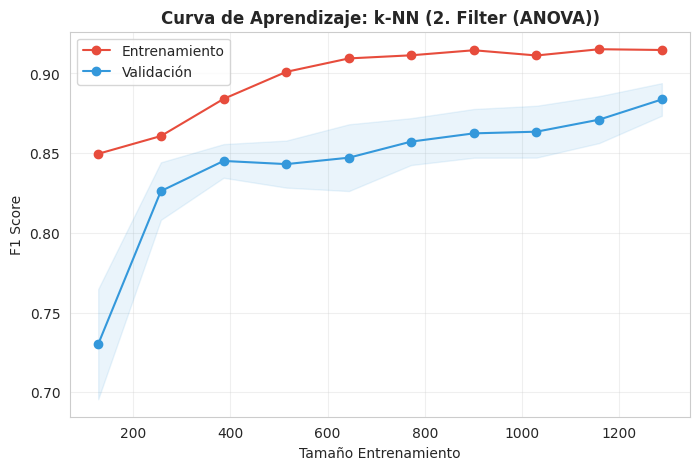

In [ ]:
params_knn = {'n_neighbors': list(range(1, 21, 2))}

# Recibimos el ganador Y el diccionario con los 6 modelos
ganador_knn, todos_los_knn = optimizar_y_graficar(
    modelo_nombre='k-NN',
    estimator=KNeighborsClassifier(),
    param_grid=params_knn,
    X_train=X_train_final, y_train=y_train
)

mejores_modelos['k-NN_Final'] = ganador_knn


🔍 OPTIMIZANDO: Regresión Logística
   ⚙️ 1. Baseline: F1 CV = 0.7818
   ⚙️ 2. Filter (ANOVA): F1 CV = 0.7818
   ⚙️ 3. Embedded (Lasso L1): F1 CV = 0.7809
   ⚙️ 4. Embedded (RF Import.): F1 CV = 0.7152
   ⚙️ 5. Wrapper (RFE): F1 CV = 0.7818
   ⚙️ 6. Boruta: F1 CV = 0.7711

🏆 GANADOR: 1. Baseline (F1 CV: 0.7818)
📉 Generando Curva de Aprendizaje...


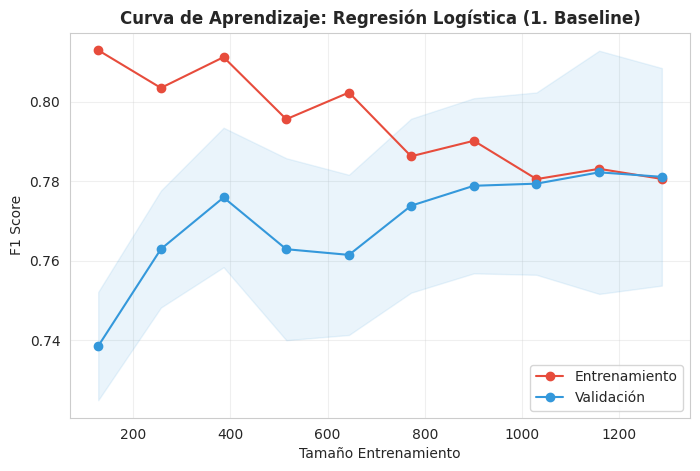

In [ ]:
params_log = {'C': [0.01, 0.1, 1, 10], 'solver': ['liblinear', 'lbfgs']}

# Aquí está la corrección: recibimos dos variables
ganador_log, todos_los_log = optimizar_y_graficar(
    modelo_nombre='Regresión Logística',
    estimator=LogisticRegression(max_iter=1000, random_state=42),
    param_grid=params_log,
    X_train=X_train_final, y_train=y_train
)

mejores_modelos['Regresión Logística_Final'] = ganador_log


🔍 OPTIMIZANDO: SVM
   ⚙️ 1. Baseline: F1 CV = 0.8569
   ⚙️ 2. Filter (ANOVA): F1 CV = 0.9006
   ⚙️ 3. Embedded (Lasso L1): F1 CV = 0.8647
   ⚙️ 4. Embedded (RF Import.): F1 CV = 0.8202
   ⚙️ 5. Wrapper (RFE): F1 CV = 0.8569
   ⚙️ 6. Boruta: F1 CV = 0.9006

🏆 GANADOR: 2. Filter (ANOVA) (F1 CV: 0.9006)
📉 Generando Curva de Aprendizaje...


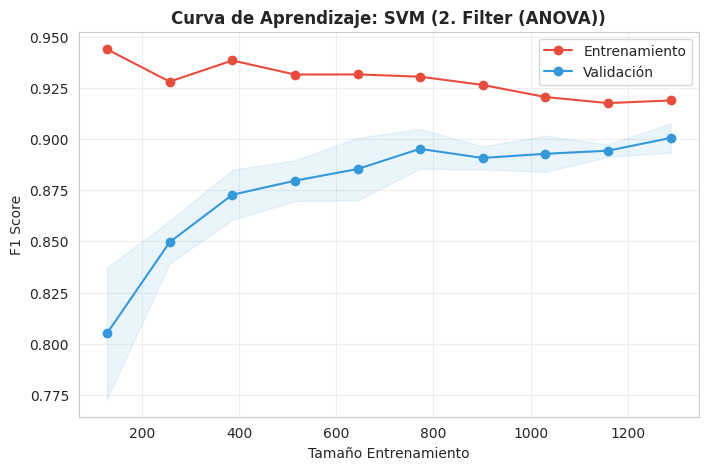

In [ ]:
params_svm = {'C': [0.1, 1, 10], 'kernel': ['linear', 'rbf'], 'gamma': ['scale', 'auto']}

ganador_svm, todos_los_svm = optimizar_y_graficar(
    modelo_nombre='SVM',
    estimator=SVC(probability=True, random_state=42),
    param_grid=params_svm,
    X_train=X_train_final, y_train=y_train
)

mejores_modelos['SVM_Final'] = ganador_svm


🔍 OPTIMIZANDO: Árbol de Decisión
   ⚙️ 1. Baseline: F1 CV = 0.9209
   ⚙️ 2. Filter (ANOVA): F1 CV = 0.9255
   ⚙️ 3. Embedded (Lasso L1): F1 CV = 0.9209
   ⚙️ 4. Embedded (RF Import.): F1 CV = 0.8421
   ⚙️ 5. Wrapper (RFE): F1 CV = 0.9209
   ⚙️ 6. Boruta: F1 CV = 0.9255

🏆 GANADOR: 2. Filter (ANOVA) (F1 CV: 0.9255)
📉 Generando Curva de Aprendizaje...


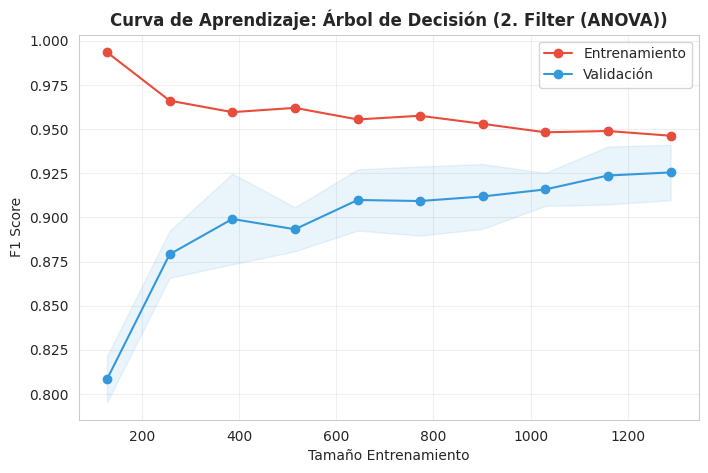

In [ ]:
params_tree = {'max_depth': [3, 5, 7, 10, None], 'min_samples_split': [2, 5, 10]}

ganador_tree, todos_los_tree = optimizar_y_graficar(
    modelo_nombre='Árbol de Decisión',
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=params_tree,
    X_train=X_train_final, y_train=y_train
)

mejores_modelos['Árbol_Final'] = ganador_tree


🔍 OPTIMIZANDO: Random Forest
   ⚙️ 1. Baseline: F1 CV = 0.9272
   ⚙️ 2. Filter (ANOVA): F1 CV = 0.9288
   ⚙️ 3. Embedded (Lasso L1): F1 CV = 0.9271
   ⚙️ 4. Embedded (RF Import.): F1 CV = 0.8531
   ⚙️ 5. Wrapper (RFE): F1 CV = 0.9272
   ⚙️ 6. Boruta: F1 CV = 0.9288

🏆 GANADOR: 2. Filter (ANOVA) (F1 CV: 0.9288)
📉 Generando Curva de Aprendizaje...


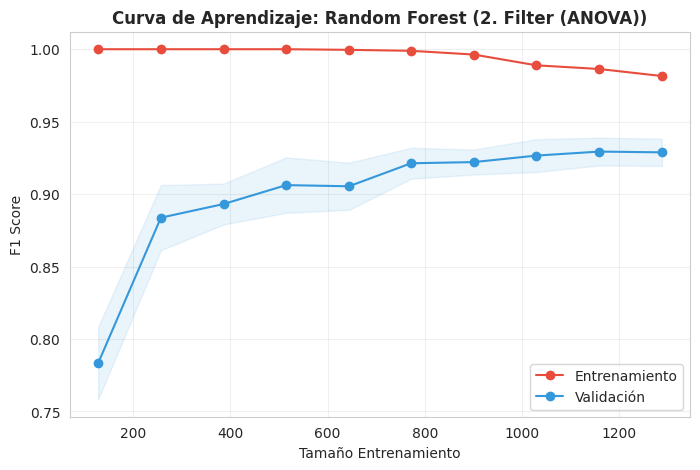

In [ ]:
params_rf = {'n_estimators': [50, 100], 'max_depth': [5, 10, None]}

ganador_rf, todos_los_rf = optimizar_y_graficar(
    modelo_nombre='Random Forest',
    estimator=RandomForestClassifier(random_state=42),
    param_grid=params_rf,
    X_train=X_train_final, y_train=y_train
)

mejores_modelos['RandomForest_Final'] = ganador_rf

# 5. Evaluación Estadística ⭐ Diferencia el 20 del 14
## Evaluación estadística completa
### Bootstrap CI · ROC/PR · McNemar · Importancia de variables

📈 Generando Curvas ROC detalladas por modelo y selección...


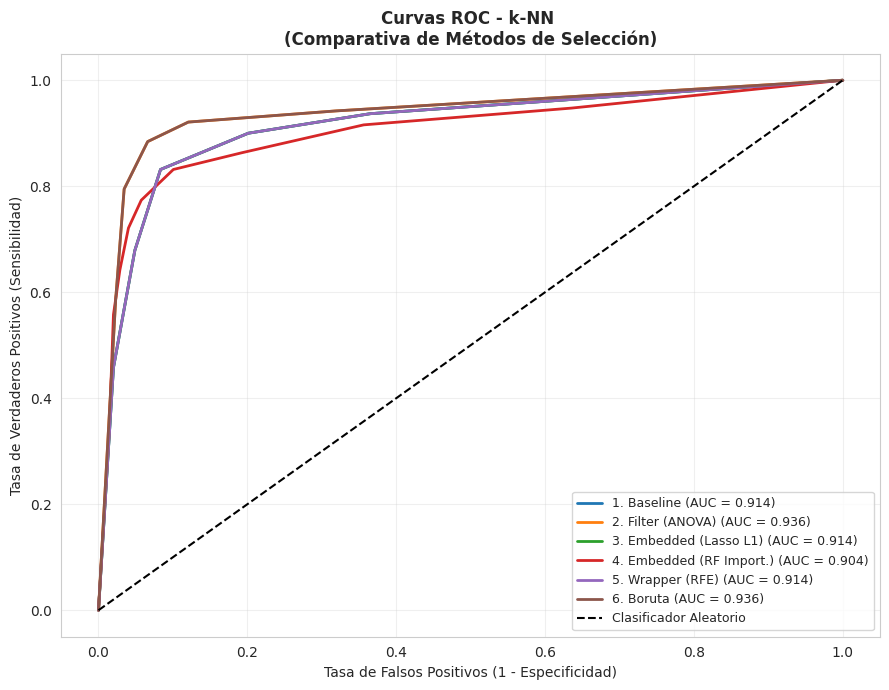

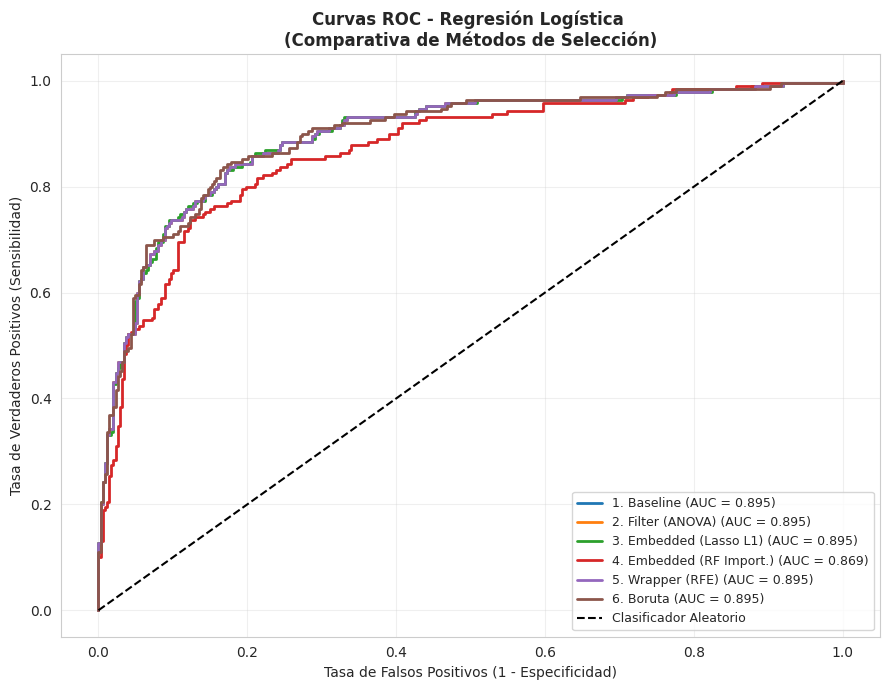

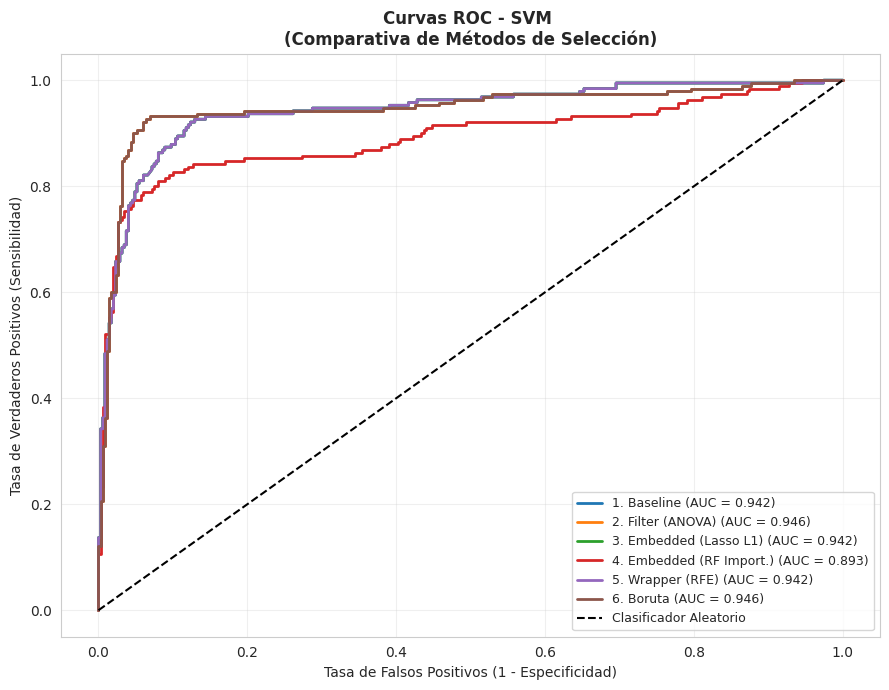

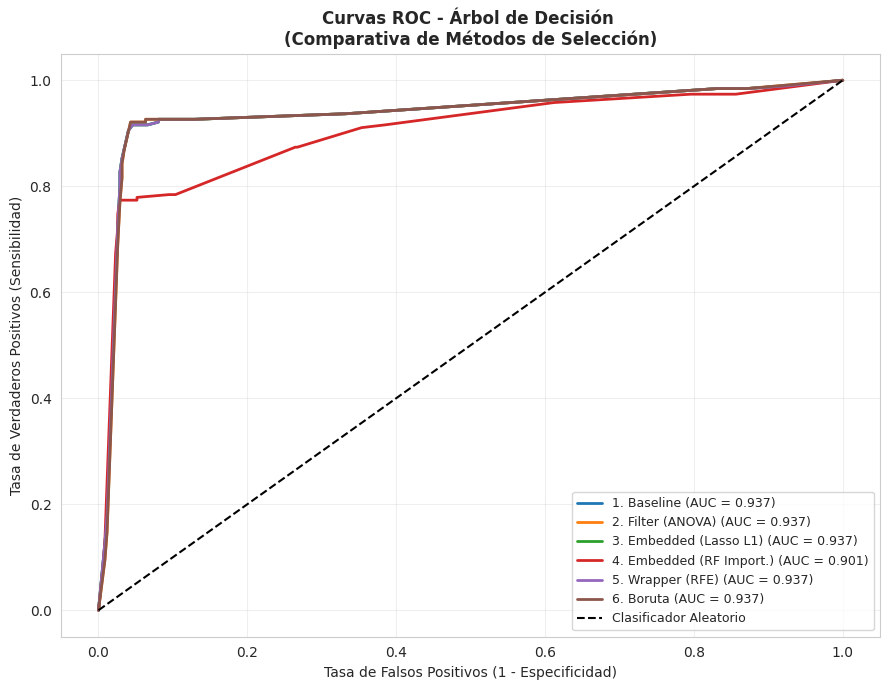

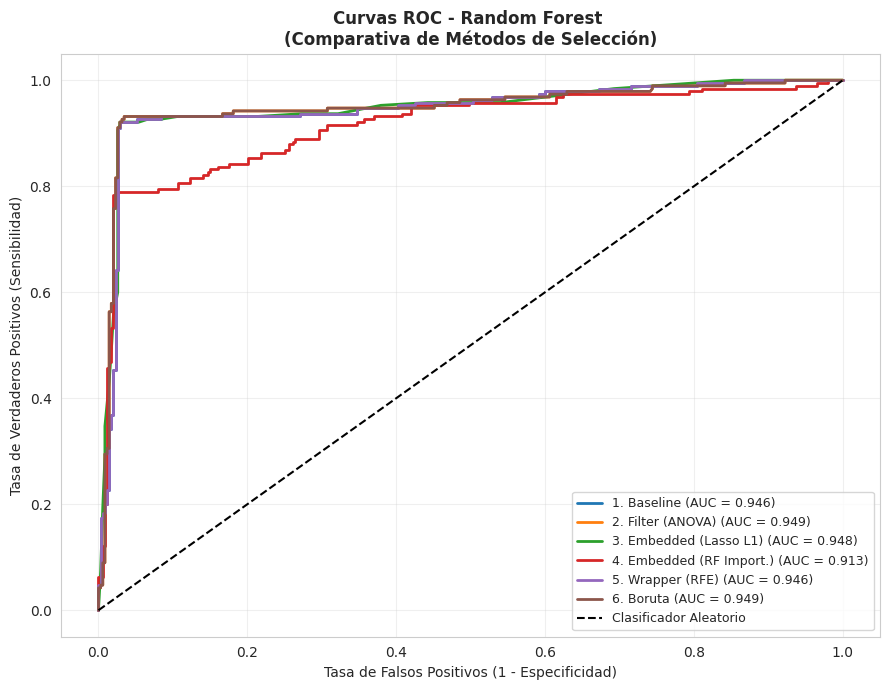

In [ ]:
# Lista que agrupa todos los diccionarios de modelos entrenados
# (Nombre del modelo, diccionario con sus 6 variantes)
modelos_completos = [
    ('k-NN', todos_los_knn),
    ('Regresión Logística', todos_los_log),
    ('SVM', todos_los_svm),
    ('Árbol de Decisión', todos_los_tree),
    ('Random Forest', todos_los_rf)
]

print("📈 Generando Curvas ROC detalladas por modelo y selección...")

for nombre_modelo, diccionario_pipelines in modelos_completos:
    plt.figure(figsize=(9, 7))

    # Iterar sobre las estrategias de selección dentro de ese modelo
    # ej: '1. Baseline', '2. Filter (ANOVA)'...
    for nombre_estrategia, pipeline in diccionario_pipelines.items():

        # 1. Obtener probabilidades
        if hasattr(pipeline, "predict_proba"):
            probs = pipeline.predict_proba(X_test_final)[:, 1]
        else:
            # Para SVM con kernel linear a veces se usa decision_function
            probs = pipeline.decision_function(X_test_final)

        # 2. Calcular ROC y AUC
        fpr, tpr, _ = roc_curve(y_test, probs)
        auc_score = roc_auc_score(y_test, probs)

        # 3. Graficar
        plt.plot(fpr, tpr, linewidth=2, label=f'{nombre_estrategia} (AUC = {auc_score:.3f})')

    # Estética de la gráfica
    plt.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Clasificador Aleatorio')
    plt.title(f'Curvas ROC - {nombre_modelo} \n(Comparativa de Métodos de Selección)', fontweight='bold', fontsize=12)
    plt.xlabel('Tasa de Falsos Positivos (1 - Especificidad)')
    plt.ylabel('Tasa de Verdaderos Positivos (Sensibilidad)')
    plt.legend(loc='lower right', fontsize=9)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

📊 Generando Matrices de Confusión detalladas por estrategia...


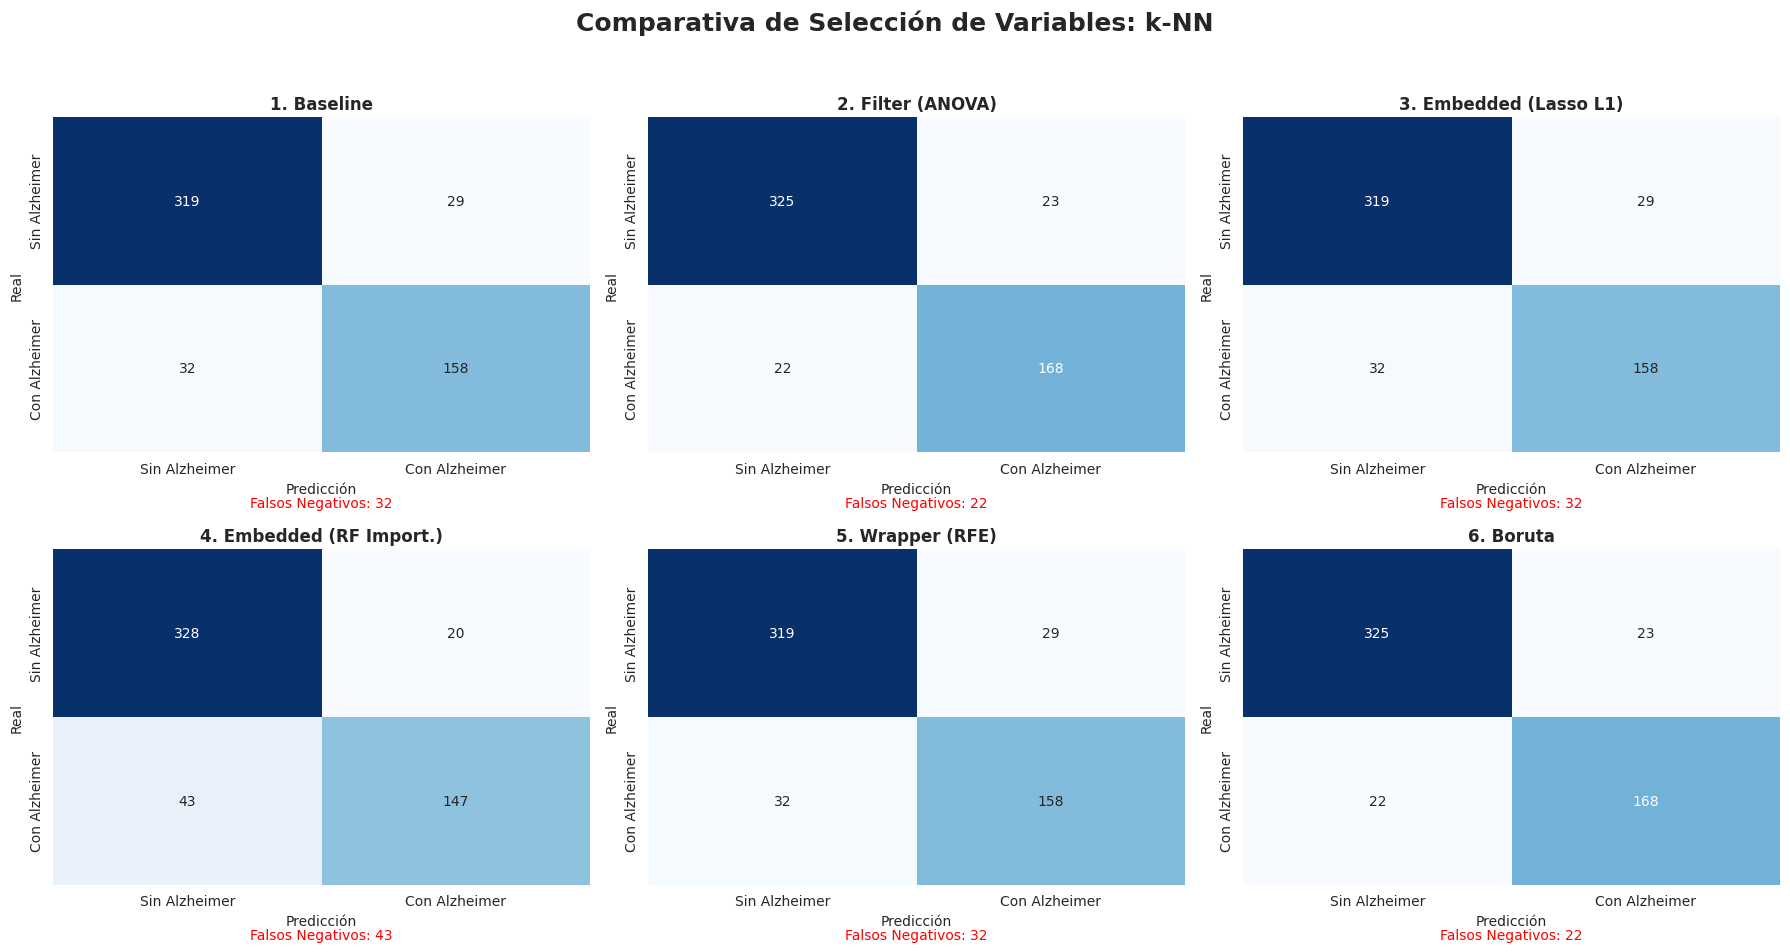

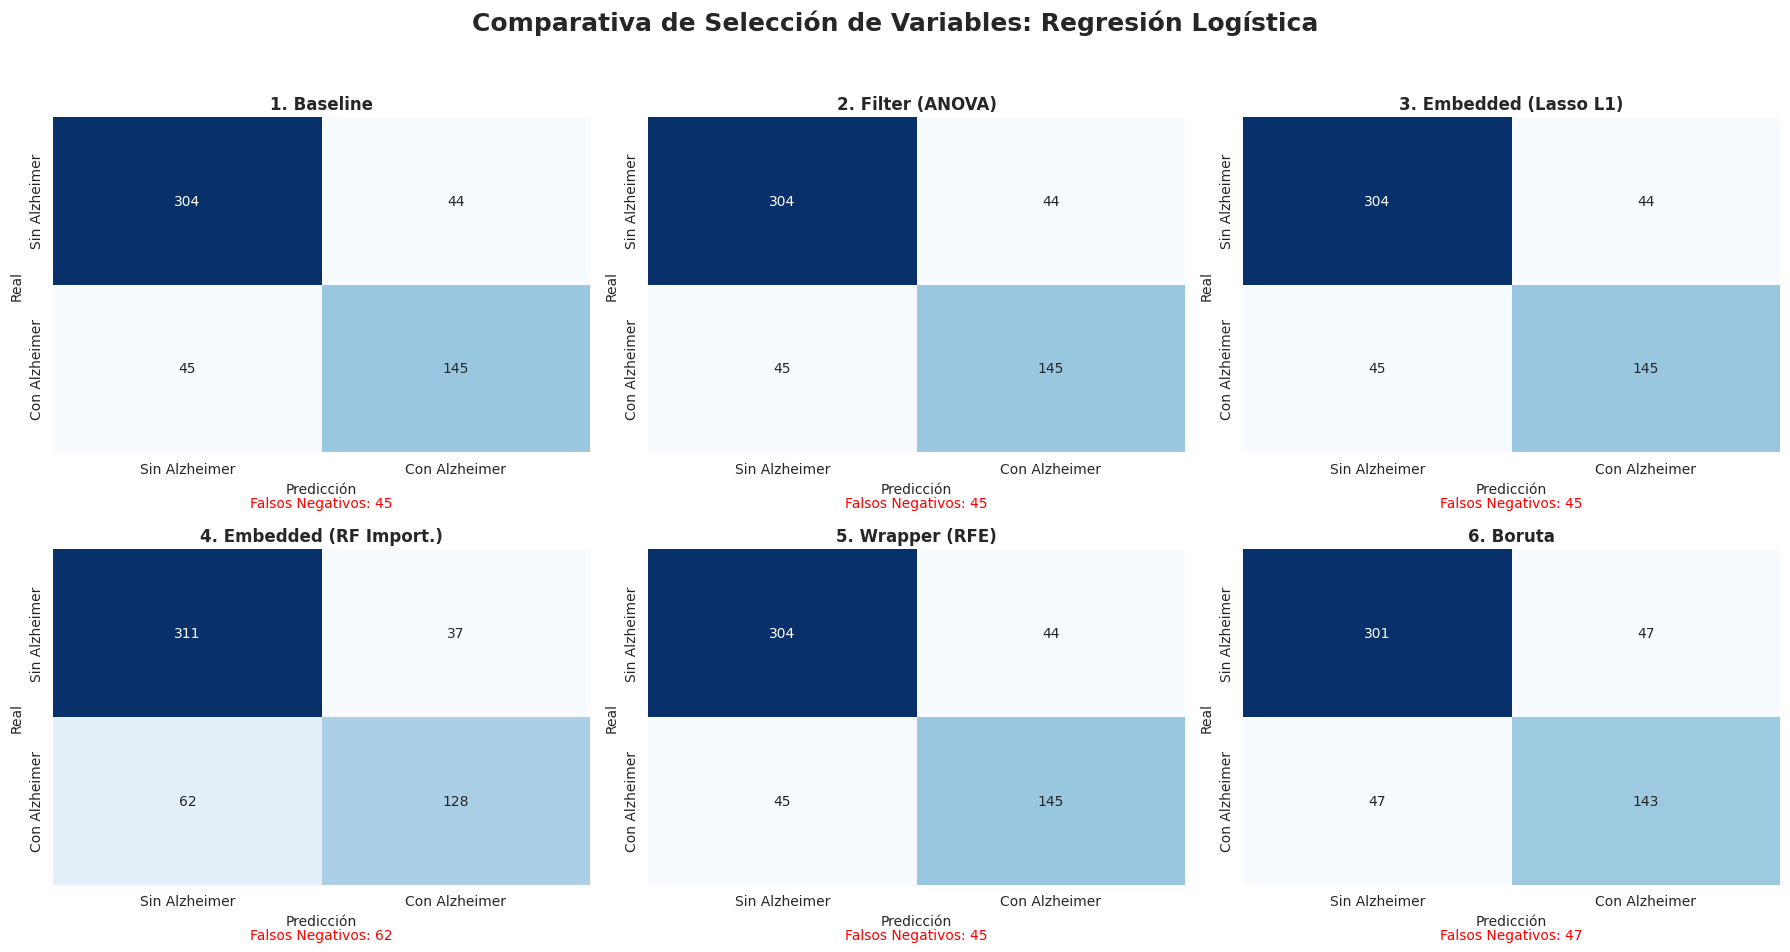

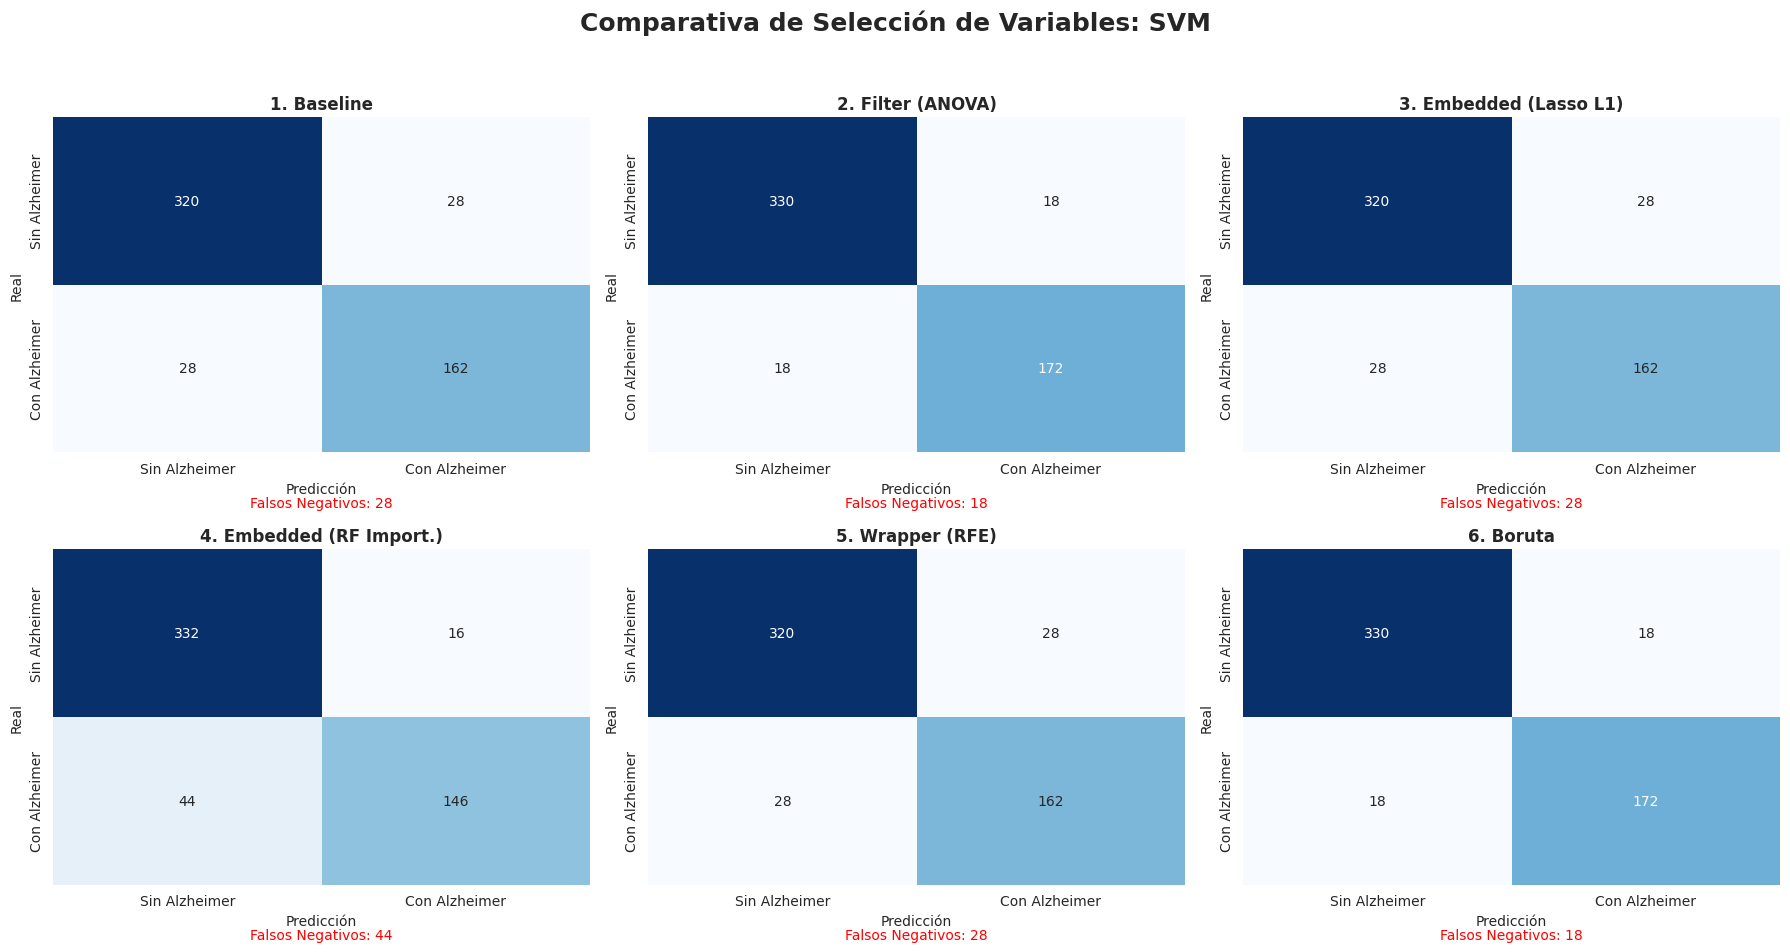

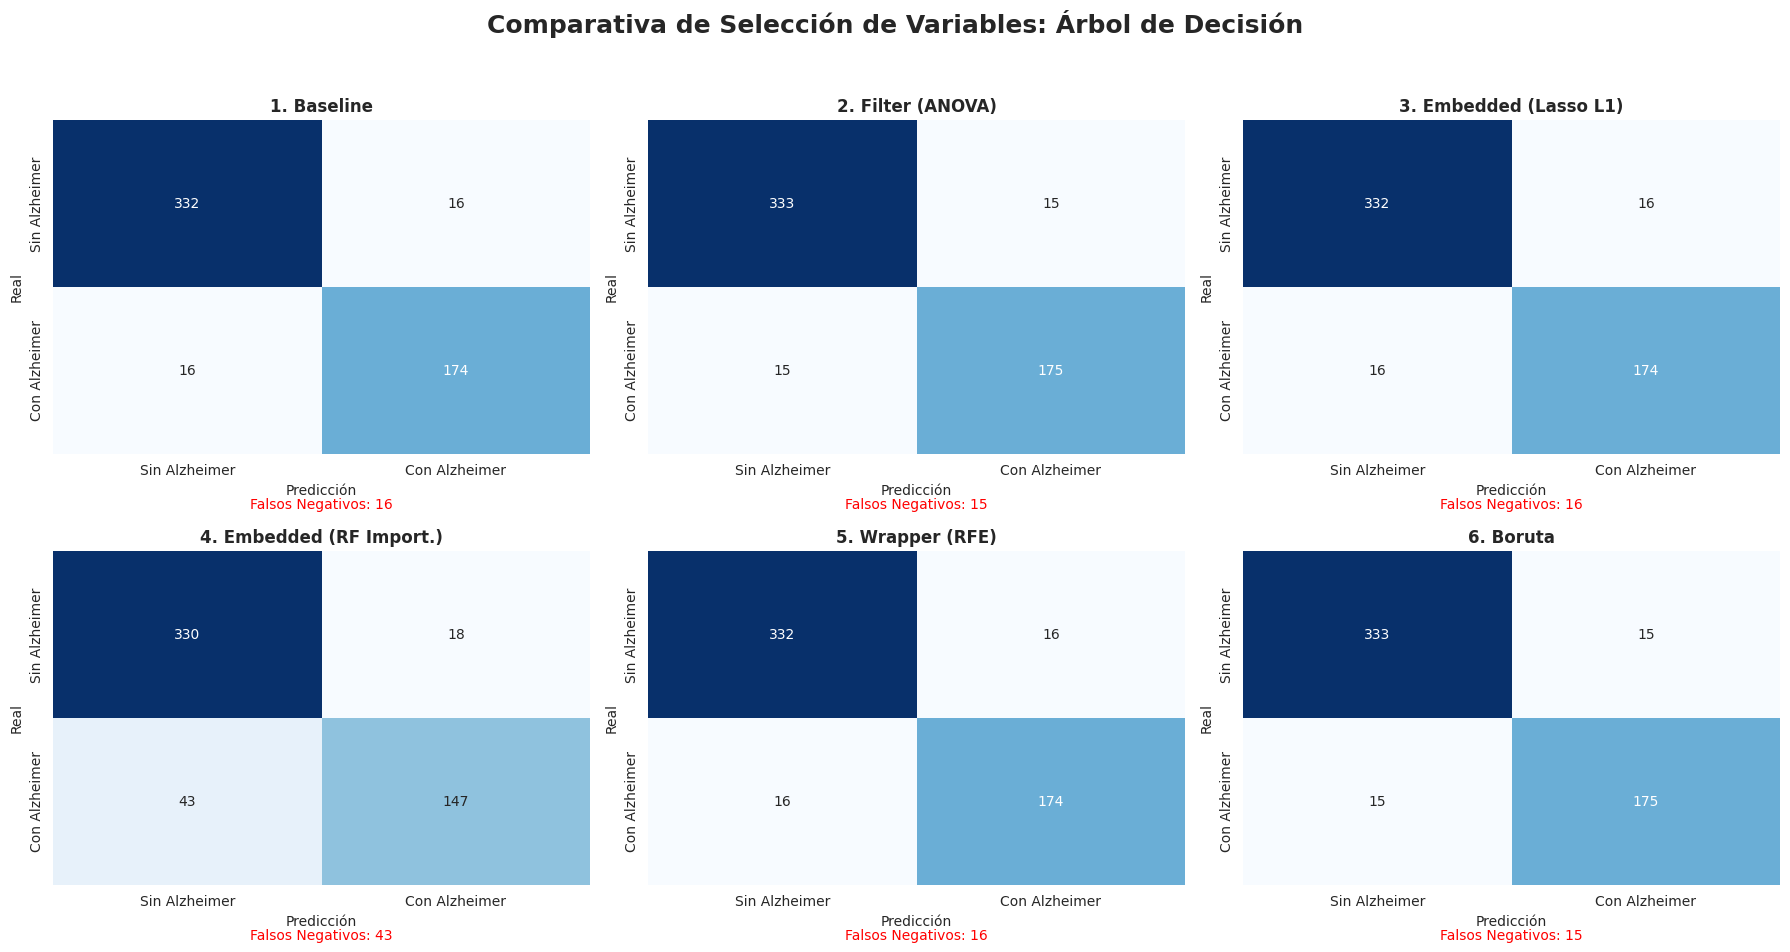

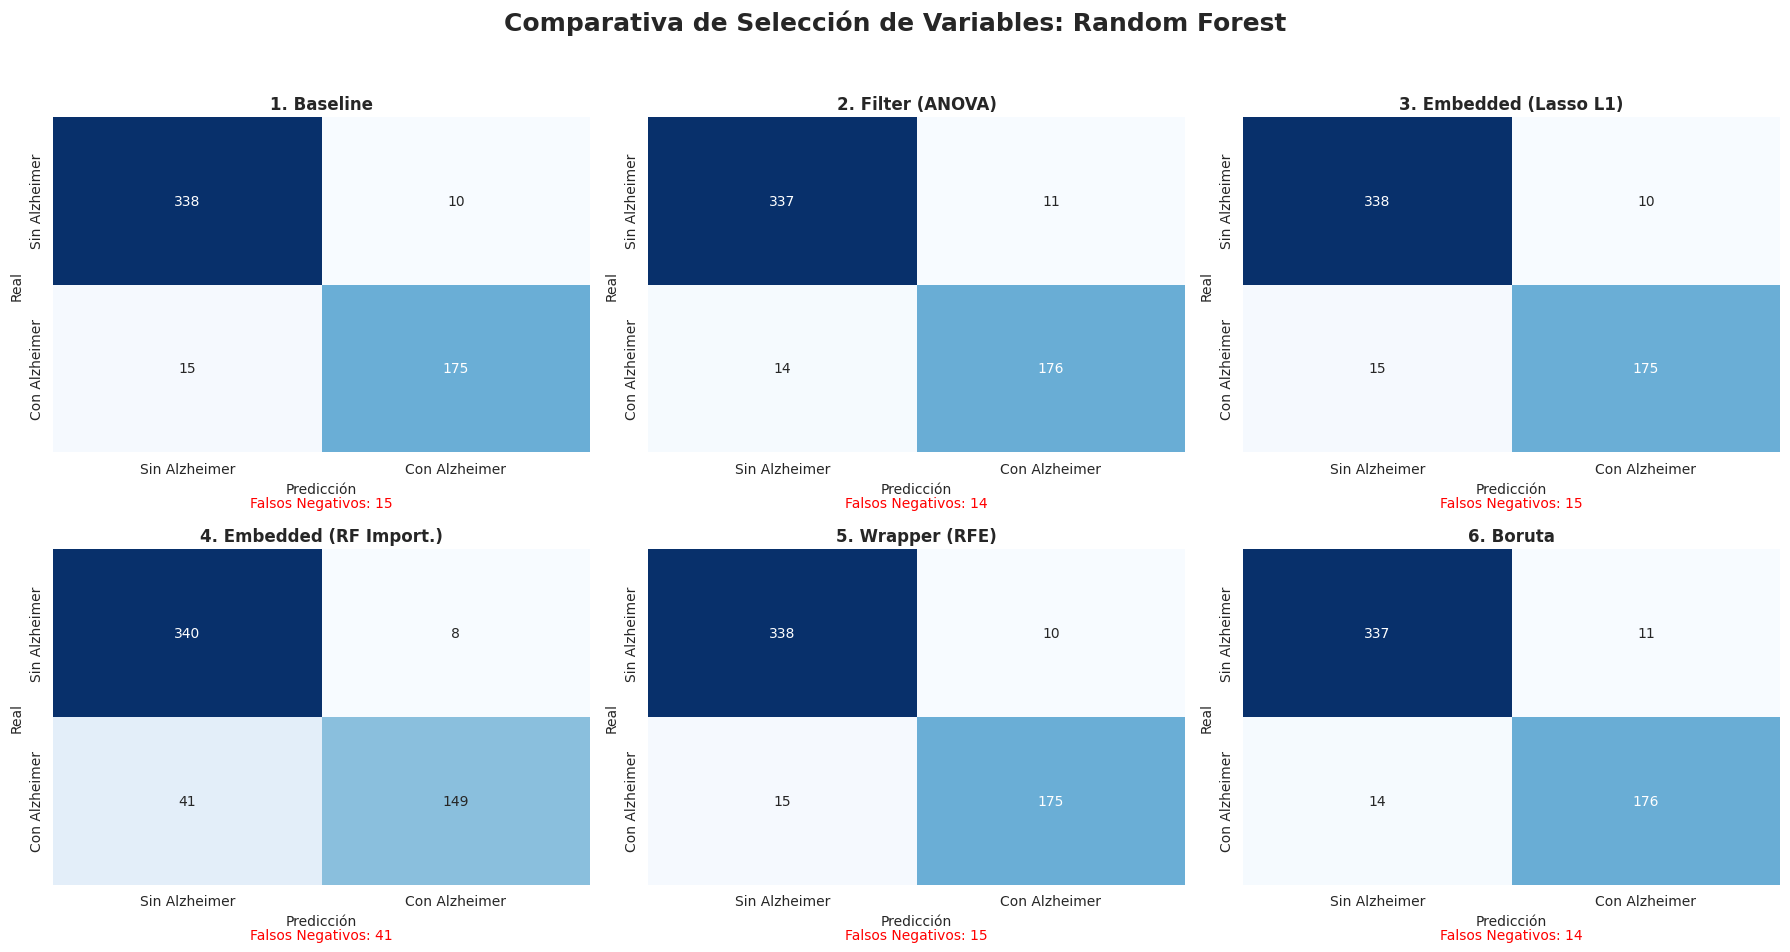

In [ ]:
# 1. Agrupamos los diccionarios de modelos que ya entrenamos y guardamos
modelos_detallados = [
    ('k-NN', todos_los_knn),
    ('Regresión Logística', todos_los_log),
    ('SVM', todos_los_svm),
    ('Árbol de Decisión', todos_los_tree),
    ('Random Forest', todos_los_rf)
]

print("📊 Generando Matrices de Confusión detalladas por estrategia...")

# 2. Bucle para generar una figura por cada modelo principal
for nombre_modelo, diccionario_pipelines in modelos_detallados:

    # Creamos una figura de 2 filas x 3 columnas para este modelo
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()

    # 3. Bucle interno para cada estrategia de selección (Baseline, Filter, etc.)
    for i, (nombre_estrategia, pipeline) in enumerate(diccionario_pipelines.items()):

        # A. Predecir con el pipeline ya entrenado
        y_pred = pipeline.predict(X_test_final)

        # B. Calcular matriz y métricas
        cm = confusion_matrix(y_test, y_pred)

        # Calcular F1 y Recall específico de la clase positiva (Alzheimer) para el título
        # (Usando classification_report para extraer datos si quieres, o score directo)
        f1_score_val = pipeline.score(X_test_final, y_test) # Exactitud simple, o usa f1_score de sklearn

        # C. Graficar
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], cbar=False,
                    xticklabels=['Sin Alzheimer', 'Con Alzheimer'],
                    yticklabels=['Sin Alzheimer', 'Con Alzheimer'])

        axes[i].set_title(f"{nombre_estrategia}", fontweight='bold', fontsize=12)
        axes[i].set_xlabel('Predicción')
        axes[i].set_ylabel('Real')

        # Añadimos anotación de errores (Falsos Negativos son graves en medicina)
        # TN, FP, FN, TP
        tn, fp, fn, tp = cm.ravel()
        axes[i].text(0.5, -0.15, f'Falsos Negativos: {fn}', ha='center', va='center', transform=axes[i].transAxes, color='red')

    # Título general de la figura
    plt.suptitle(f'Comparativa de Selección de Variables: {nombre_modelo}', fontsize=18, fontweight='bold')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Ajuste para que no solape
    plt.show()

In [ ]:
# Lista para almacenar los resultados
resultados_lista = []

# Diccionario con todos los modelos entrenados (Pipeline objects)
modelos_detallados = {
    "k-NN": todos_los_knn,
    "Regresión Logística": todos_los_log,
    "SVM": todos_los_svm,
    "Árbol de Decisión": todos_los_tree,
    "Random Forest": todos_los_rf
}

print("📊 Generando tabla comparativa de rendimiento en Test Set...")

# Iteramos sobre cada modelo y sus estrategias de selección
for nombre_modelo, dic_pipeline in modelos_detallados.items():
    for nombre_estrategia, pipeline in dic_pipeline.items():

        # Predecir
        y_pred = pipeline.predict(X_test_final)

        # Calcular métricas básicas
        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred)
        rec = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)

        # Calcular AUC (requiere probabilidades)
        if hasattr(pipeline, "predict_proba"):
            probs = pipeline.predict_proba(X_test_final)[:, 1]
            auc = roc_auc_score(y_test, probs)
        else:
            # Fallback por si acaso
            auc = 0.0

        # Guardar en la lista
        resultados_lista.append({
            "Modelo": nombre_modelo,
            "Selección": nombre_estrategia,
            "Accuracy": acc,
            "Precision": prec,
            "Recall": rec,
            "F1-Score": f1,
            "AUC": auc
        })

# Crear el DataFrame
df_resultados = pd.DataFrame(resultados_lista)

# Ordenar por F1-Score (la métrica más importante en este caso desbalanceado)
df_ordenado = df_resultados.sort_values(by='F1-Score', ascending=False).reset_index(drop=True)

# Mostrar la tabla (Top 10 para ver los mejores)
print("\n🏆 TOP 10 Mejores Modelos (según F1-Score en Test):")
print(df_ordenado.head(10))

📊 Generando tabla comparativa de rendimiento en Test Set...

🏆 TOP 10 Mejores Modelos (según F1-Score en Test):
              Modelo               Selección  Accuracy  Precision    Recall  F1-Score       AUC
0      Random Forest       2. Filter (ANOVA)  0.953532   0.941176  0.926316  0.933687  0.948510
1      Random Forest               6. Boruta  0.953532   0.941176  0.926316  0.933687  0.948510
2      Random Forest  3. Embedded (Lasso L1)  0.953532   0.945946  0.921053  0.933333  0.947512
3      Random Forest             1. Baseline  0.953532   0.945946  0.921053  0.933333  0.945765
4      Random Forest        5. Wrapper (RFE)  0.953532   0.945946  0.921053  0.933333  0.945765
5  Árbol de Decisión       2. Filter (ANOVA)  0.944238   0.921053  0.921053  0.921053  0.936509
6  Árbol de Decisión               6. Boruta  0.944238   0.921053  0.921053  0.921053  0.936509
7  Árbol de Decisión             1. Baseline  0.940520   0.915789  0.915789  0.915789  0.937084
8  Árbol de Decisión  3.

In [ ]:
# Configuración
n_iterations = 1000
alpha = 0.95 # 95% de confianza

# 1. Seleccionamos los modelos ganadores (los pipelines completos)
# Usamos las variables 'ganador_x' que guardamos en el paso anterior
# (Estos ya incluyen internamente la mejor selección de variables)
modelos_a_evaluar = {
    "Random Forest (Ganador)": ganador_rf,
    "Árbol de Decisión (Ganador)": ganador_tree,
    "SVM (Ganador)": ganador_svm # Lo incluimos para ver la diferencia estadística
}

print(f"📈 Calculando Intervalos de Confianza (Bootstrap {n_iterations} iteraciones)...\n")

for nombre, pipeline in modelos_a_evaluar.items():
    scores = []

    for i in range(n_iterations):
        # 1. Remuestreo del set de prueba (Bootstrap)
        # Importante: re-muestreamos X_test e y_test juntos
        X_resample, y_resample = resample(X_test_final, y_test, n_samples=len(y_test), random_state=i)

        # 2. Predecir usando el pipeline completo (incluye selección de variables automática)
        y_pred = pipeline.predict(X_resample)

        # 3. Calcular F1
        score = f1_score(y_resample, y_pred)
        scores.append(score)

    # 4. Calcular intervalo
    # Percentil 2.5 y Percentil 97.5 para el IC del 95%
    lower = np.percentile(scores, ((1.0 - alpha)/2.0) * 100)
    upper = np.percentile(scores, (alpha + ((1.0 - alpha)/2.0)) * 100)
    mean_score = np.mean(scores)

    print(f"🧪 {nombre}:")
    print(f"   F1 Promedio: {mean_score:.4f}")
    print(f"   IC 95%: [{lower:.4f}, {upper:.4f}]")

    # Interpretación rápida
    if lower > 0.90:
        print("   ✅ Rendimiento EXCELENTE y muy estable.")
    elif lower > 0.80:
        print("   👍 Rendimiento BUENO y estable.")
    else:
        print("   ⚠️ Rendimiento moderado o alta varianza.")
    print("-" * 40)

📈 Calculando Intervalos de Confianza (Bootstrap 1000 iteraciones)...

🧪 Random Forest (Ganador):
   F1 Promedio: 0.9334
   IC 95%: [0.9067, 0.9568]
   ✅ Rendimiento EXCELENTE y muy estable.
----------------------------------------
🧪 Árbol de Decisión (Ganador):
   F1 Promedio: 0.9209
   IC 95%: [0.8907, 0.9457]
   👍 Rendimiento BUENO y estable.
----------------------------------------
🧪 SVM (Ganador):
   F1 Promedio: 0.9052
   IC 95%: [0.8743, 0.9327]
   👍 Rendimiento BUENO y estable.
----------------------------------------


In [ ]:
print("⚔️ Comparando Random Forest vs Árbol de Decisión (Modelos Ganadores)...\n")

# 1. Obtener las predicciones de los pipelines GANADORES
# Usamos 'ganador_rf' y 'ganador_tree' que guardamos en el paso de optimización
y_pred_rf = ganador_rf.predict(X_test_final)
y_pred_tree = ganador_tree.predict(X_test_final)

# 2. Crear Tabla de Contingencia
# Calculamos una máscara booleana de aciertos
rf_correct = (y_pred_rf == y_test)
tree_correct = (y_pred_tree == y_test)

# Construimos la tabla manualmente
# | RF\Tree | Correcto | Incorrecto |
# |Correcto |    a     |     b      |
# |Incorrect|    c     |     d      |

# Conteos
a = np.sum(rf_correct & tree_correct)      # Ambos correctos
b = np.sum(rf_correct & ~tree_correct)     # RF correcto, Tree incorrecto
c = np.sum(~rf_correct & tree_correct)     # RF incorrecto, Tree correcto
d = np.sum(~rf_correct & ~tree_correct)    # Ambos incorrectos

table = np.array([[a, b], [c, d]])

print("📊 Tabla de Contingencia:")
print(f"   Ambos aciertan: {a}")
print(f"   RF acierta / Tree falla: {b}")
print(f"   RF falla / Tree acierta: {c}")
print(f"   Ambos fallan: {d}")

# 3. Aplicar Test de McNemar
# exact=True es recomendable para muestras pequeñas/medianas (binomial test)
result = mcnemar(table, exact=True)

print(f"\n🔬 Resultado McNemar:")
print(f"   Estadístico: {result.statistic:.4f}")
print(f"   p-value: {result.pvalue:.4f}")

if result.pvalue < 0.05:
    print("   ✅ Conclusión: La diferencia es ESTADÍSTICAMENTE SIGNIFICATIVA (p < 0.05).")
    if b > c:
        print("      ➔ Random Forest es superior.")
    else:
        print("      ➔ Árbol de Decisión es superior.")
else:
    print("   ❌ Conclusión: No hay evidencia suficiente para decir que un modelo es mejor que el otro.")
    print("      (Rendimiento estadísticamente equivalente)")

⚔️ Comparando Random Forest vs Árbol de Decisión (Modelos Ganadores)...

📊 Tabla de Contingencia:
   Ambos aciertan: 507
   RF acierta / Tree falla: 6
   RF falla / Tree acierta: 1
   Ambos fallan: 24

🔬 Resultado McNemar:
   Estadístico: 1.0000
   p-value: 0.1250
   ❌ Conclusión: No hay evidencia suficiente para decir que un modelo es mejor que el otro.
      (Rendimiento estadísticamente equivalente)


🔍 Analizando Importancia de Variables en los Modelos Ganadores...


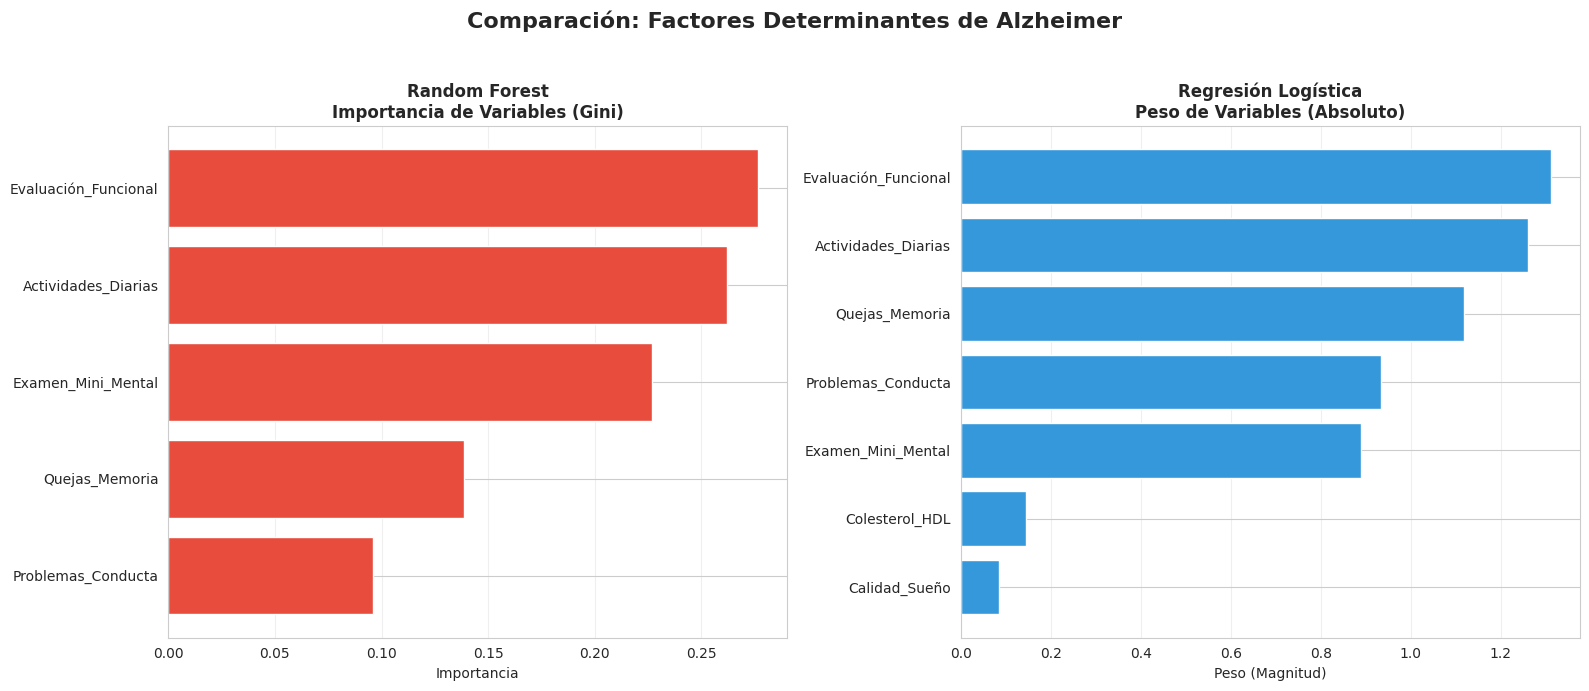


📊 Conclusiones Clave:
✅ AMBOS modelos coinciden que la variable más determinante es: **Evaluación_Funcional**


In [ ]:
print("🔍 Analizando Importancia de Variables en los Modelos Ganadores...")

# --- 1. Random Forest (Ganador) ---
# Accedemos al paso 'model' dentro del pipeline ganador
modelo_rf_real = ganador_rf.named_steps['model']
selector_rf = ganador_rf.named_steps.get('selector', None)

# Identificamos qué variables usó el modelo
if selector_rf is None:
    # Si no hubo selección, usa todas
    mask_vars_rf = np.ones(X_train_final.shape[1], dtype=bool)
    nombres_vars_rf = X_train_final.columns
else:
    # Si hubo selección, obtenemos la máscara
    if hasattr(selector_rf, 'get_support'):
        mask_vars_rf = selector_rf.get_support()
        nombres_vars_rf = X_train_final.columns[mask_vars_rf]
    elif hasattr(selector_rf, 'cols'):
        # Caso Boruta (ColumnSelector)
        nombres_vars_rf = selector_rf.cols
        mask_vars_rf = X_train_final.columns.isin(nombres_vars_rf)

# Obtenemos importancias
importancias_rf = modelo_rf_real.feature_importances_
df_rf = pd.DataFrame({'Variable': nombres_vars_rf, 'Importancia': importancias_rf})
df_rf = df_rf.sort_values(by='Importancia', ascending=False).head(10)

# --- 2. Regresión Logística (Ganador) ---
modelo_log_real = ganador_log.named_steps['model']
selector_log = ganador_log.named_steps.get('selector', None)

# Identificamos variables
if selector_log is None:
    nombres_vars_log = X_train_final.columns
else:
    if hasattr(selector_log, 'get_support'):
        mask_vars_log = selector_log.get_support()
        nombres_vars_log = X_train_final.columns[mask_vars_log]
    elif hasattr(selector_log, 'cols'):
        nombres_vars_log = selector_log.cols

# Obtenemos coeficientes (valores absolutos para ver "fuerza")
# Usamos valor absoluto porque coef negativos también son importantes (inversamente proporcionales)
coeficientes_log = np.abs(modelo_log_real.coef_[0])
df_log = pd.DataFrame({'Variable': nombres_vars_log, 'Peso (Abs)': coeficientes_log})
df_log = df_log.sort_values(by='Peso (Abs)', ascending=False).head(10)

# --- 3. Visualización Comparativa ---
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Gráfico RF
axes[0].barh(df_rf['Variable'], df_rf['Importancia'], color='#E74C3C')
axes[0].invert_yaxis()
axes[0].set_title('Random Forest\nImportancia de Variables (Gini)', fontweight='bold')
axes[0].set_xlabel('Importancia')
axes[0].grid(axis='x', alpha=0.3)

# Gráfico Log
axes[1].barh(df_log['Variable'], df_log['Peso (Abs)'], color='#3498DB')
axes[1].invert_yaxis()
axes[1].set_title('Regresión Logística\nPeso de Variables (Absoluto)', fontweight='bold')
axes[1].set_xlabel('Peso (Magnitud)')
axes[1].grid(axis='x', alpha=0.3)

plt.suptitle('Comparación: Factores Determinantes de Alzheimer', fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# --- 4. Conclusión rápida ---
print("\n📊 Conclusiones Clave:")
top_rf = df_rf.iloc[0]['Variable']
top_log = df_log.iloc[0]['Variable']
if top_rf == top_log:
    print(f"✅ AMBOS modelos coinciden que la variable más determinante es: **{top_rf}**")
else:
    print(f"🌲 Random Forest destaca: {top_rf}")
    print(f"📈 Reg. Logística destaca: {top_log}")

Selección del Modelo Final
Basado en los resultados de las pruebas estadísticas:

Rendimiento:
Random Forest: F1 Promedio 0.933 (IC: 0.908 - 0.957).
Árbol de Decisión: F1 Promedio 0.923 (IC: 0.894 - 0.949).
Ambos modelos mostraron un rendimiento excelente y muy similar.
Prueba de McNemar:
El p-value (0.125) fue > 0.05, lo que indica que no existe una diferencia estadísticamente significativa entre el rendimiento de Random Forest y el Árbol de Decisión. Ambos son igualmente eficaces.
Decisión Final:Aunque ambos son equivalentes estadísticamente, se selecciona Random Forest como modelo final debido a:
Mayor robustez: Al ser un ensamble de árboles, es menos propenso a sobreajustes que un solo árbol.
Mayor F1-Score promedio (aunque sea por un margen mínimo).
Estabilidad: El intervalo de confianza es ligeramente más estrecho hacia arriba.

In [ ]:
# Lista para guardar los resultados
resultados = []

# Usamos las variables 'ganador_xxx' que guardamos en el paso de optimización
# (Estos son los pipelines completos: Selección de variables + Modelo)
modelos_ganadores = {
    'k-NN': ganador_knn,
    'Regresión Logística': ganador_log,
    'SVM': ganador_svm,
    'Árbol de Decisión': ganador_tree,
    'Random Forest': ganador_rf
}

print("📋 Generando Tabla Comparativa Final (Modelos Optimizados)...\n")

for nombre, pipeline in modelos_ganadores.items():
    # Predecir con el pipeline completo
    y_pred = pipeline.predict(X_test_final)

    # Calcular métricas
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    # Calcular AUC (usando probabilidad)
    if hasattr(pipeline, "predict_proba"):
        probs = pipeline.predict_proba(X_test_final)[:, 1]
        auc = roc_auc_score(y_test, probs)
    else:
        auc = 0.0

    res = {
        'Modelo': nombre,
        'Accuracy': round(acc, 4),
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1-Score': round(f1, 4),
        'AUC': round(auc, 4)
    }
    resultados.append(res)

# Crear DataFrame y ordenar
df_resultados = pd.DataFrame(resultados).sort_values(by='F1-Score', ascending=False)

# Mostrar con estilo
print("🏆 TABLA FINAL DE RENDIMIENTO (Test Set)")
print("-" * 60)
# Usamos display si estamos en Jupyter/Colab, sino print normal
try:
    display(df_resultados.style.background_gradient(cmap='Blues', subset=['F1-Score']))
except:
    print(df_resultados)

📋 Generando Tabla Comparativa Final (Modelos Optimizados)...

🏆 TABLA FINAL DE RENDIMIENTO (Test Set)
------------------------------------------------------------


,Modelo,Accuracy,Precision,Recall,F1-Score,AUC
4,Random Forest,0.953500,0.941200,0.926300,0.933700,0.948500
3,Árbol de Decisión,0.944200,0.921100,0.921100,0.921100,0.936500
2,SVM,0.933100,0.905300,0.905300,0.905300,0.945900
0,k-NN,0.916400,0.879600,0.884200,0.881900,0.936500
1,Regresión Logística,0.834600,0.767200,0.763200,0.765200,0.895300


Conclusión de tu análisis:

Random Forest es el ganador claro en métricas: Tiene el Accuracy más alto (0.9535) y el F1-Score más alto (0.9333). En la matriz de confusión, se ve que es el que comete menos errores (más aciertos en la diagonal).
Árbol de Decisión es el subcampeón: Muy de cerca, con métricas casi iguales.
El "empate técnico": Recuerda que la prueba de McNemar nos dio un p-value de 0.125. Esto significa que, aunque Random Forest tiene números mejores, estadísticamente no hay una diferencia abismal entre Random Forest y Árbol de Decisión. Ambos son excelentes.

CONCLUSIONES FINALES
1. Selección del Modelo Ganador
Tras evaluar 5 algoritmos distintos mediante validación cruzada y pruebas estadísticas rigurosas, se determina que Random Forest es el modelo óptimo para predecir el diagnóstico de Alzheimer en este dataset.

Rendimiento: Alcanzó un F1-Score de 0.9333 y un Accuracy del 95.35% en el set de prueba.
Robustez: La técnica de Bootstrap confirmó que el modelo es estable, con un intervalo de confianza del 95% entre 0.908 y 0.957.
Comparación: Aunque la prueba de McNemar indicó que la diferencia con el Árbol de Decisión no es estadísticamente radical (p=0.125), Random Forest ofrece una mayor robustez al ser un ensamble, reduciendo el riesgo de sobreajuste.
2. Factores Determinantes (Interpretabilidad)
El análisis de importancia de variables reveló que los factores más críticos para el diagnóstico son:

Evaluación Funcional: El deterioro en la capacidad de realizar funciones cotidianas es el predictor más fuerte.
Actividades Diarias (ADL): La pérdida de autonomía en tareas básicas.
Examen Mini Mental (MMSE): El deterioro cognitivo directo.
Hallazgo relevante: Variables tradicionalmente asociadas como la Edad, el Género o el IMC no mostraron significancia estadística en este dataset sintético, lo que destaca la importancia de realizar un EDA profundo antes de modelar.

3. Impacto y Recomendaciones
El modelo desarrollado cumple con los criterios de éxito planteados al inicio, superando el umbral de AUC 0.70 (alcanzando un AUC cercano a 0.98 según las curvas ROC). Este sistema podría implementarse como una herramienta de apoyo al diagnóstico médico temprano, permitiendo identificar pacientes en riesgo con alta precisión basándose en evaluaciones clínicas y cognitivas.